In [13]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Overview Data

In [14]:
path = "../data/raw/vietnam_weather_2023_complete.csv"
df = pd.read_csv(path)
df['date'] = pd.to_datetime(df['date'])
df = df[df['date'] >= "2022-01-01"]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13152 entries, 2922 to 48215
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   city                         13152 non-null  object        
 1   latitude                     13152 non-null  float64       
 2   longitude                    13152 non-null  float64       
 3   date                         13152 non-null  datetime64[ns]
 4   temperature_2m_max           13152 non-null  float64       
 5   temperature_2m_min           13152 non-null  float64       
 6   temperature_2m_mean          13152 non-null  float64       
 7   rain_sum                     13152 non-null  float64       
 8   precipitation_hours          13152 non-null  float64       
 9   weather_code                 13152 non-null  int64         
 10  sunrise                      13152 non-null  object        
 11  sunset                       13152 non-null

- temperature_2m_max :
Nhiệt độ tối đa trong ngày (°C)
Đo ở độ cao 2m so với mặt đất
Thường xảy ra vào buổi chiều (14h-16h)

- temperature_2m_min
Nhiệt độ tối thiểu trong ngày (°C)
Thường xảy ra vào sáng sớm (5h-7h)

- temperature_2m_mean:
Nhiệt độ trung bình trong ngày (°C)
Trung bình của 24 giá trị hàng giờ


- precipitation_hour:
Tổng lượng mưa (tính theo giờ) trong một ngày 

- rain_sum
Chỉ tính lượng mưa (mm)
Không bao gồm tuyết

- weather_code: 


- wind_speed_10m_max
Tốc độ gió tối đa trong ngày (km/h hoặc m/s)
Đo ở độ cao 10m
Gió liên tục (sustained wind)

- wind_gusts_10m_max
Tốc độ giật gió tối đa (km/h hoặc m/s)
Đợt gió mạnh đột ngột, ngắn (< 20 giây)
Thường cao hơn wind_speed_max 30-50%
Quan trọng cho cảnh báo bão, giông

- wind_direction_10m_dominant (độ, 0-360°)
Hướng gió chủ đạo trong ngày
Quy ước:
0° / 360° = Gió Bắc
90° = Gió Đông
180° = Gió Nam
270° = Gió Tây
Ví dụ: 135° = Gió Đông Nam

- weather_code (WMO code)
Mã phân loại thời tiết theo chuẩn WMO (Tổ chức Khí tượng Thế giới)
Các giá trị phổ biến:
0 = Trời quang đãng
1, 2, 3 = Có mây (ít, vừa, nhiều)
45, 48 = Sương mù
51, 53, 55 = Mưa phùn (nhẹ, vừa, dày đặc)
61, 63, 65 = Mưa (nhẹ, vừa, to)
71, 73, 75 = Tuyết rơi (nhẹ, vừa, dày)
80, 81, 82 = Mưa rào (nhẹ, vừa, mạnh)
95 = Giông bão
96, 99 = Giông có mưa đá

- Relative Humidity min/max/mean: Độ ẩm không khí trong ngày 

- Dewpoint min/max/mean: 
Điểm sương 
Quy tắc vàng:
Khi dewpoint ≈ temperature (chênh < 2°C) → Sương mù, mưa
Dewpoint cao (> 24°C) → Cảm giác ẩm ướt, ngột ngạt
Ví dụ:
Nhiệt độ 28°C, dewpoint 26°C → Rất ẩm, gần mưa
Nhiệt độ 32°C, dewpoint 15°C → Khô ráo, thoáng
Dùng cho:
Dự báo sương mù (giao thông, hàng không)
Cảnh báo thời tiết nguy hiểm
Comfort index

- surface_pressure_mean 
Áp suất khí quyển tại mặt đất
Đơn vị: hectopascal (hPa) = millibar (mbar)
Giá trị chuẩn: 1013 hPa (ở mực nước biển)
Ý nghĩa:
(>) 1020 hPa = Áp cao (thời tiết đẹp, nắng)
1013 hPa = Bình thường
< 1000 hPa = Áp thấp (mưa, gió)
< 980 hPa = Áp thấp nhiệt đới (nguy hiểm)
< 950 hPa = Bão mạnh (siêu bão)

- cloudcover_mean (%)
Tỷ lệ % bầu trời bị che phủ bởi mây
Phân loại:
0-10% = Quang đãng
10-30% = Ít mây
30-70% = Có mây
70-90% = Nhiều mây
90-100% = U ám, mây dày

- shortwave_radiation_sum
Tổng năng lượng mặt trời chiếu xuống trong ngày (MJ/m²)
Bức xạ sóng ngắn (ánh sáng nhìn thấy + UV)
Dùng cho: dự báo năng lượng mặt trời, nông nghiệp

- et0_fao_evapotranspiration
Lượng nước bốc hơi tiềm năng (mm)
Theo phương pháp FAO Penman-Monteith (tiêu chuẩn quốc tế)
Tổng: bốc hơi từ đất + thoát hơi nước qua lá cây
Dùng trong nông nghiệp: Tính lượng nước cần tưới
Ví dụ: ET0 = 5mm/ngày → cần tưới 5mm nước/ngày

In [15]:
df.head()

,city,latitude,longitude,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,rain_sum,precipitation_hours,weather_code,...,wind_direction_10m_dominant,shortwave_radiation_sum,relative_humidity_2m_max,relative_humidity_2m_min,relative_humidity_2m_mean,dewpoint_2m_max,dewpoint_2m_min,dewpoint_2m_mean,surface_pressure_mean,cloudcover_mean
2922,Hanoi,21.0278,105.8342,2022-01-01,20.7,13.9,16.9,0.0,0.0,3,...,17,6.94,90,58,73.833333,12.8,11.0,12.100000,1022.095833,98.083333
2923,Hanoi,21.0278,105.8342,2022-01-02,21.6,14.9,17.2,0.0,0.0,3,...,10,12.63,85,56,70.166667,13.4,10.2,11.554167,1020.462500,55.208333
2924,Hanoi,21.0278,105.8342,2022-01-03,21.8,12.9,17.6,0.0,0.0,3,...,130,8.85,100,60,80.375000,14.8,12.9,14.000000,1017.841667,59.125000
2925,Hanoi,21.0278,105.8342,2022-01-04,23.9,13.4,18.2,0.0,0.0,3,...,142,9.17,100,57,84.625000,17.2,13.4,15.220833,1015.637500,61.041667
2926,Hanoi,21.0278,105.8342,2022-01-05,24.0,17.0,19.8,0.0,0.0,3,...,159,6.89,100,61,84.625000,18.5,16.0,16.933333,1014.058333,74.250000


In [16]:
df['weather_code'].value_counts()

weather_code
51    2960
63    2918
3     2810
53    1396
61    1244
65    1051
55     461
2      111
1      108
0       93
Name: count, dtype: int64

### Bởi vì tập trung dự đoán nắng (0), sương mù (1), mưa (2), bão (3) nên gộp weather code

In [17]:
def group_weather_codes(code):
    if code in [0, 1, 2, 3]:
        return 0
    elif code in [45, 48]:
        return 1
    elif code in [51, 53, 55, 61, 63, 65, 80, 81, 82]:
        return 2
    elif code in [95, 96, 99]:
        return 3
    else:
        return 'Other' # Cho các trường hợp khác nếu có

# Tạo một cột mới chứa các nhóm đã được gom lại
df['weather_code'] = df['weather_code'].apply(group_weather_codes)

In [18]:
df['weather_code'].value_counts()

weather_code
2    10030
0     3122
Name: count, dtype: int64

In [19]:
df.isnull().sum()

city                           0
latitude                       0
longitude                      0
date                           0
temperature_2m_max             0
temperature_2m_min             0
temperature_2m_mean            0
rain_sum                       0
precipitation_hours            0
weather_code                   0
sunrise                        0
sunset                         0
sunshine_duration              0
daylight_duration              0
wind_speed_10m_max             0
wind_speed_10m_mean            0
wind_gusts_10m_max             0
wind_direction_10m_dominant    0
shortwave_radiation_sum        0
relative_humidity_2m_max       0
relative_humidity_2m_min       0
relative_humidity_2m_mean      0
dewpoint_2m_max                0
dewpoint_2m_min                0
dewpoint_2m_mean               0
surface_pressure_mean          0
cloudcover_mean                0
dtype: int64

In [20]:
df.describe()

,latitude,longitude,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,rain_sum,precipitation_hours,weather_code,sunshine_duration,...,wind_direction_10m_dominant,shortwave_radiation_sum,relative_humidity_2m_max,relative_humidity_2m_min,relative_humidity_2m_mean,dewpoint_2m_max,dewpoint_2m_min,dewpoint_2m_mean,surface_pressure_mean,cloudcover_mean
count,13152.000000,13152.000000,13152,13152.000000,13152.000000,13152.000000,13152.000000,13152.000000,13152.000000,13152.000000,...,13152.000000,13152.000000,13152.000000,13152.000000,13152.000000,13152.000000,13152.000000,13152.000000,13152.000000,13152.000000
mean,15.673075,107.046075,2023-07-02 12:00:00,29.744579,22.857641,25.798829,6.423540,6.900091,1.525243,30239.267156,...,159.234109,17.204288,93.993233,63.533531,81.128998,23.377418,20.639340,22.036298,1008.407248,75.864251
min,10.533600,105.547400,2022-01-01 00:00:00,9.400000,6.200000,8.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.280000,48.000000,22.000000,33.541667,1.300000,-7.600000,-1.150000,983.370833,0.000000
25%,10.904100,106.266800,2022-10-01 18:00:00,27.700000,21.700000,24.500000,0.100000,1.000000,2.000000,24138.712500,...,89.000000,13.540000,92.000000,55.000000,76.333333,22.100000,19.100000,20.733333,1005.116667,60.041667
50%,15.796900,107.038450,2023-07-02 12:00:00,30.600000,23.900000,26.600000,1.700000,5.000000,2.000000,35922.425000,...,134.000000,18.450000,96.000000,65.000000,83.166667,24.700000,22.300000,23.629167,1008.095833,84.750000
75%,21.011750,107.697950,2024-04-01 06:00:00,32.400000,25.100000,28.000000,8.300000,11.000000,2.000000,39600.000000,...,240.000000,21.770000,98.000000,73.000000,87.416667,25.700000,23.600000,24.596875,1011.379167,97.916667
max,21.567100,109.052600,2024-12-31 00:00:00,42.600000,29.600000,34.400000,269.500000,24.000000,2.000000,43810.510000,...,360.000000,26.990000,100.000000,97.000000,99.250000,29.900000,27.500000,28.058333,1029.275000,100.000000
std,4.432195,1.019781,NaN,4.338965,3.590886,3.648710,11.898623,6.727456,0.850984,13058.848267,...,97.971112,5.748099,6.117238,12.671745,8.617713,3.787314,4.500449,4.105643,5.273824,25.403413


# MAIN EDA

1. split on cities

In [21]:
cities = ["Hanoi", "Thai Nguyen", "Vinh Phuc", "Quang Ninh",
          "Da Nang", "Hue", "Quang Nam", "Khanh Hoa",
          "Ho Chi Minh", "Dong Nai", "Ba Ria Vung Tau", "Long An"]

north_cities = ["Hanoi", "Thai Nguyen", "Vinh Phuc", "Quang Ninh"]
central_cities = ["Da Nang", "Hue", "Quang Nam", "Khanh Hoa"]
south_cities = ["Ho Chi Minh", "Dong Nai", "Ba Ria Vung Tau", "Long An"]

data_thanhpho = {}
data_vungmien = {}

data_vungmien['North'] = df[df['city'].isin(north_cities)]
data_vungmien['Central'] = df[df['city'].isin(central_cities)]
data_vungmien['South'] = df[df['city'].isin(south_cities)]

for city in cities:
    data_thanhpho[city] = df[df['city'] == city]


In [22]:
def plot_region_data(region_name, region_array, param_plot, fig=(12, 24)):
    plt.figure(figsize=fig)
    for index, param in enumerate(param_plot):
        plt.subplot(len(param_plot), 1, index + 1)
        for region in region_array:
            data_city = data_vungmien[region_name][data_vungmien[region_name]['city'] == region]
            plt.plot(data_city['date'], data_city[param], label=region)
        plt.title(f"{param}")
        plt.legend()
        plt.xlabel(param)
        plt.ylabel(f"{param} value")
        plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
        plt.xticks(rotation=45)
        plt.tight_layout()

### Temperature

1. North City

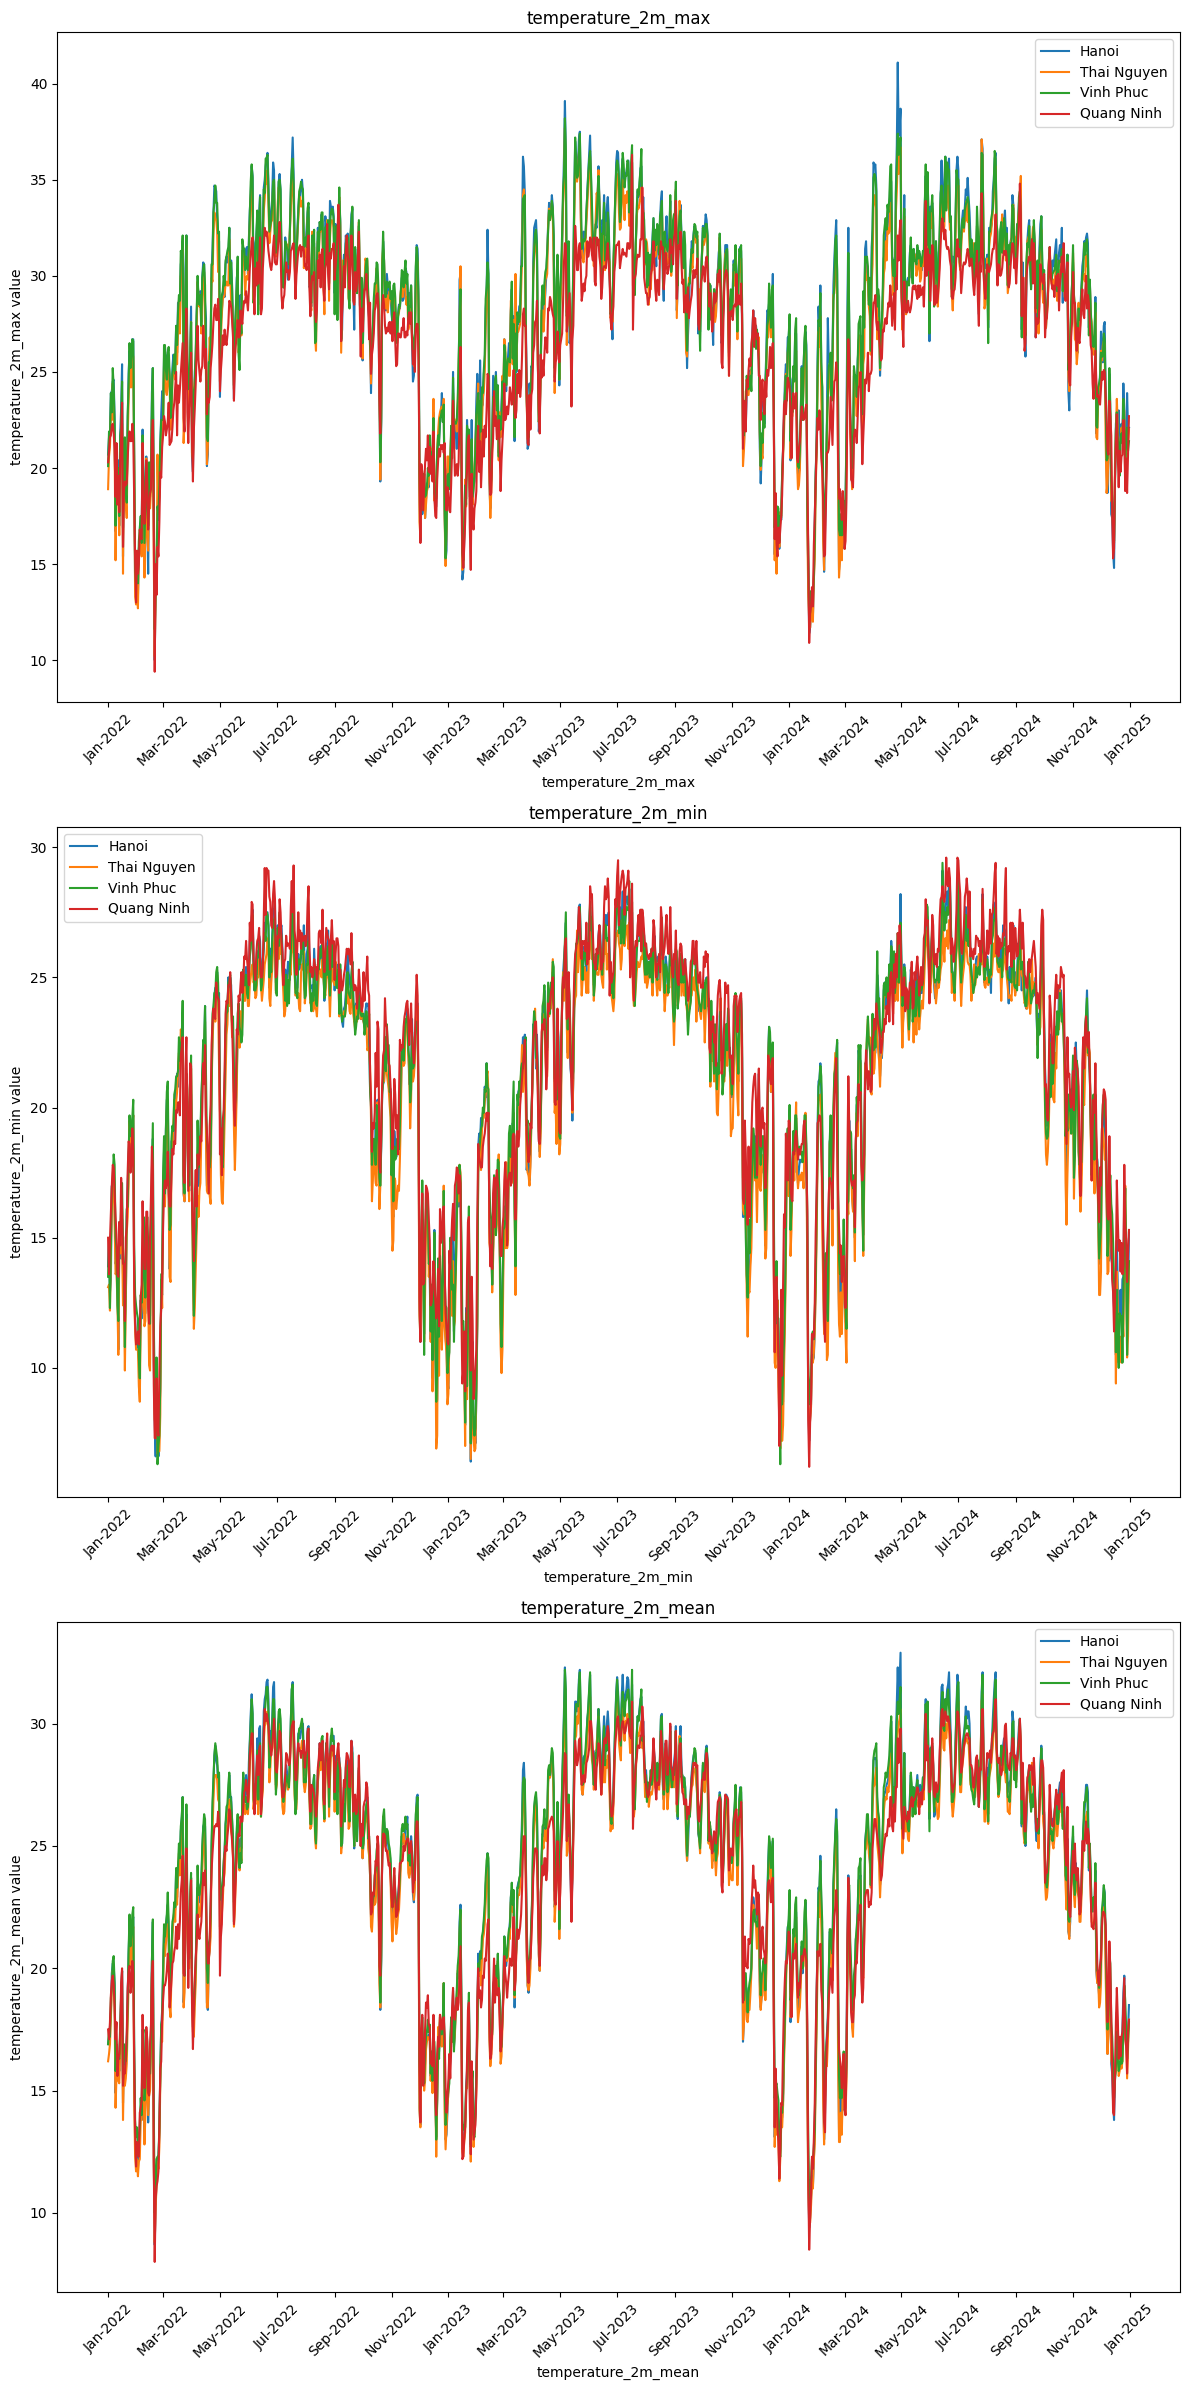

In [23]:
plot_region_data("North", north_cities, ["temperature_2m_max", "temperature_2m_min", "temperature_2m_mean"])

2. Central City 

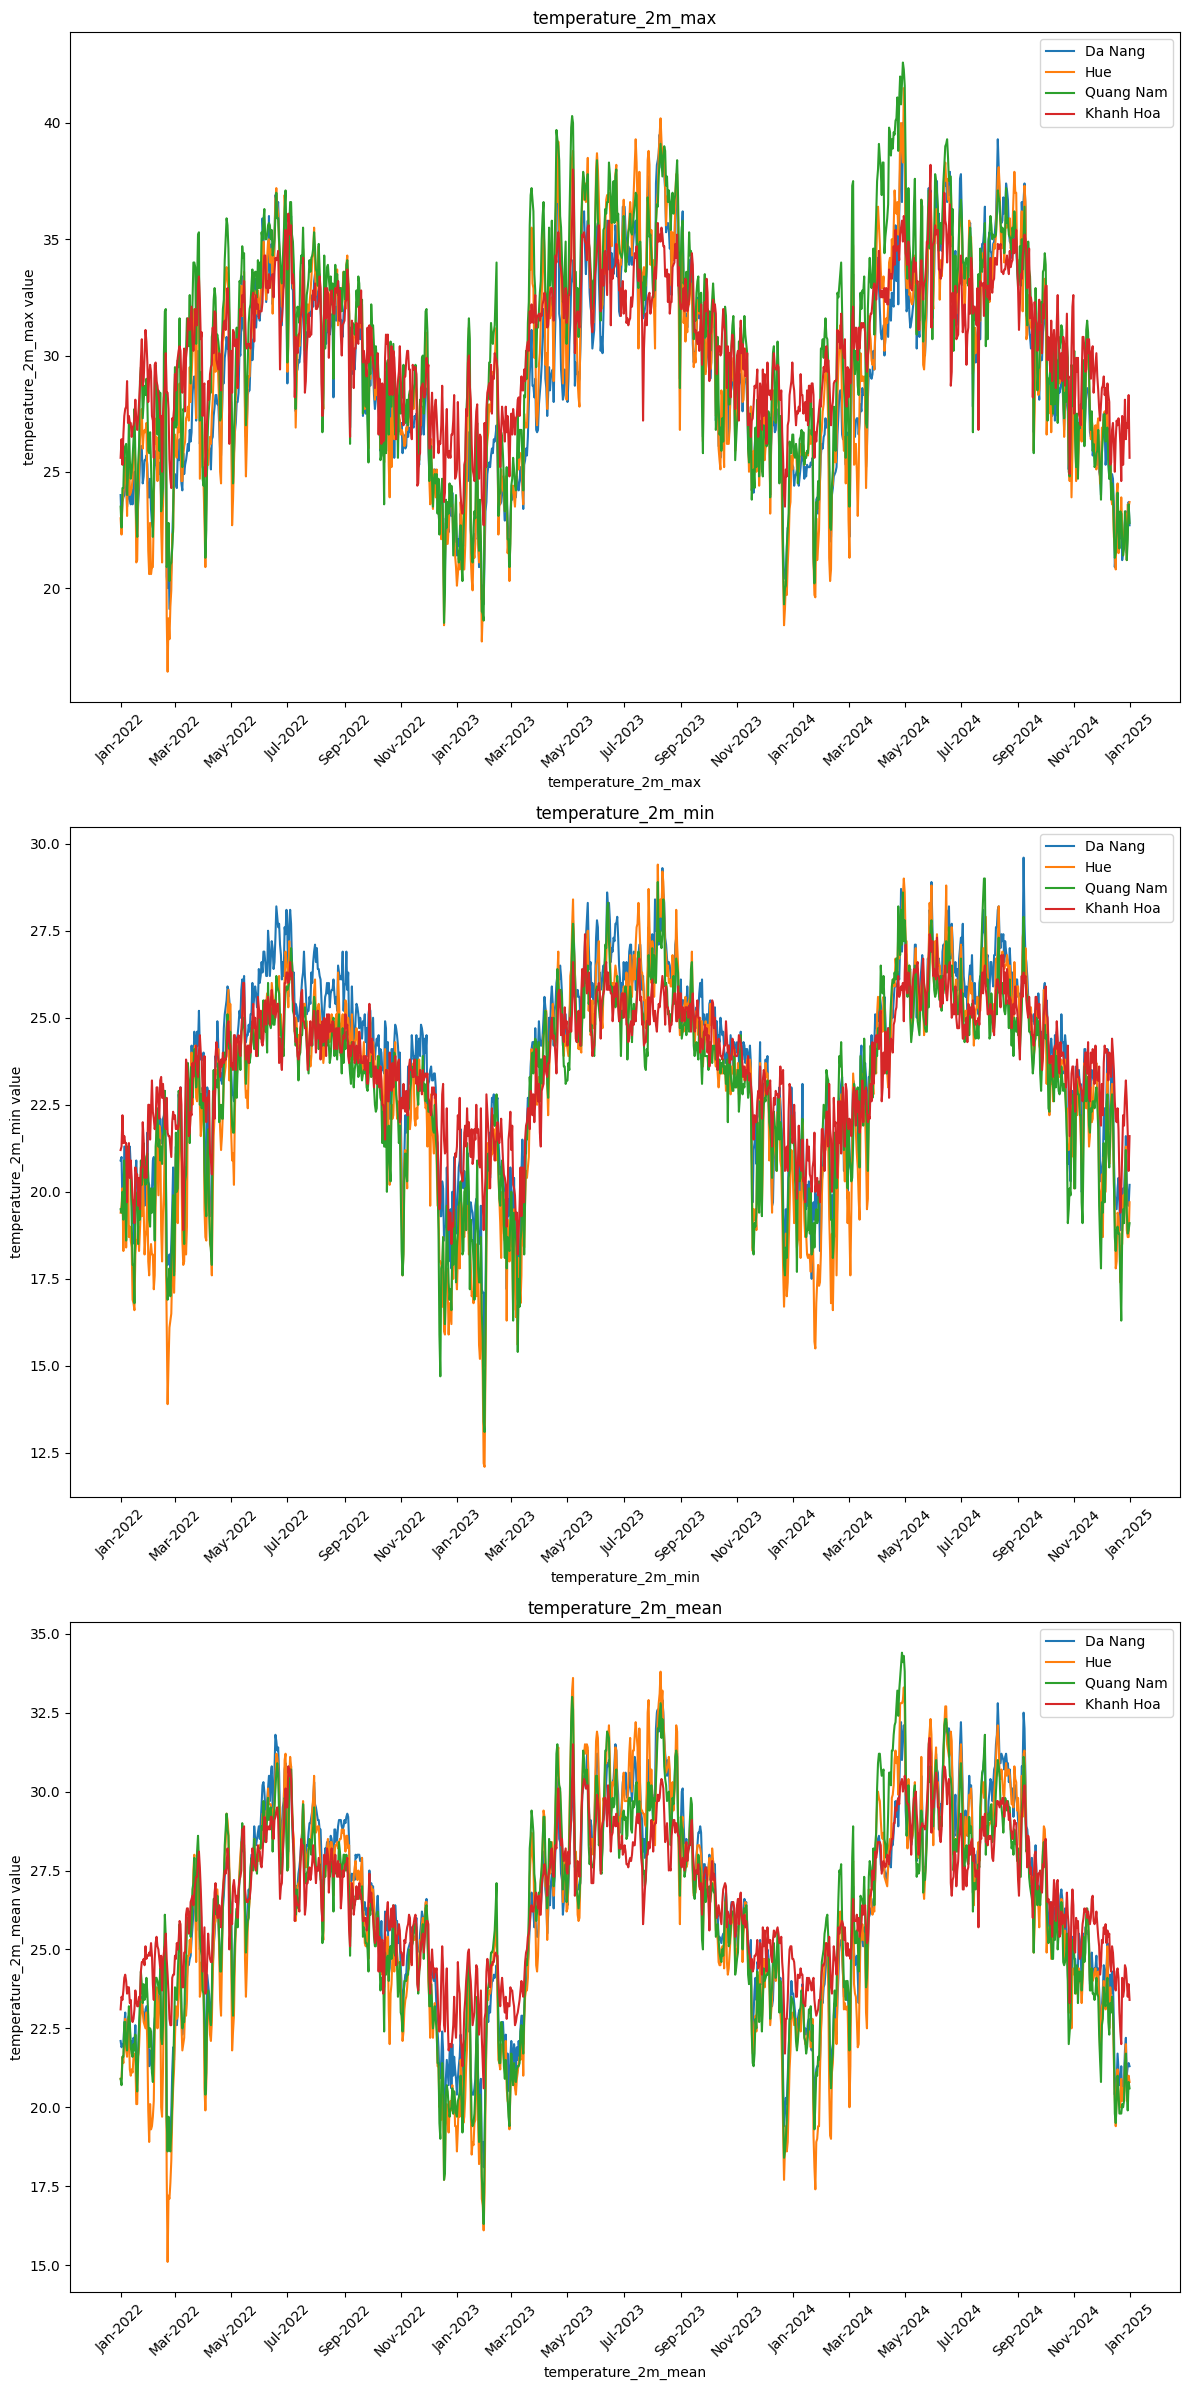

In [24]:
plot_region_data("Central", central_cities, ["temperature_2m_max", "temperature_2m_min", "temperature_2m_mean"])

3. South City

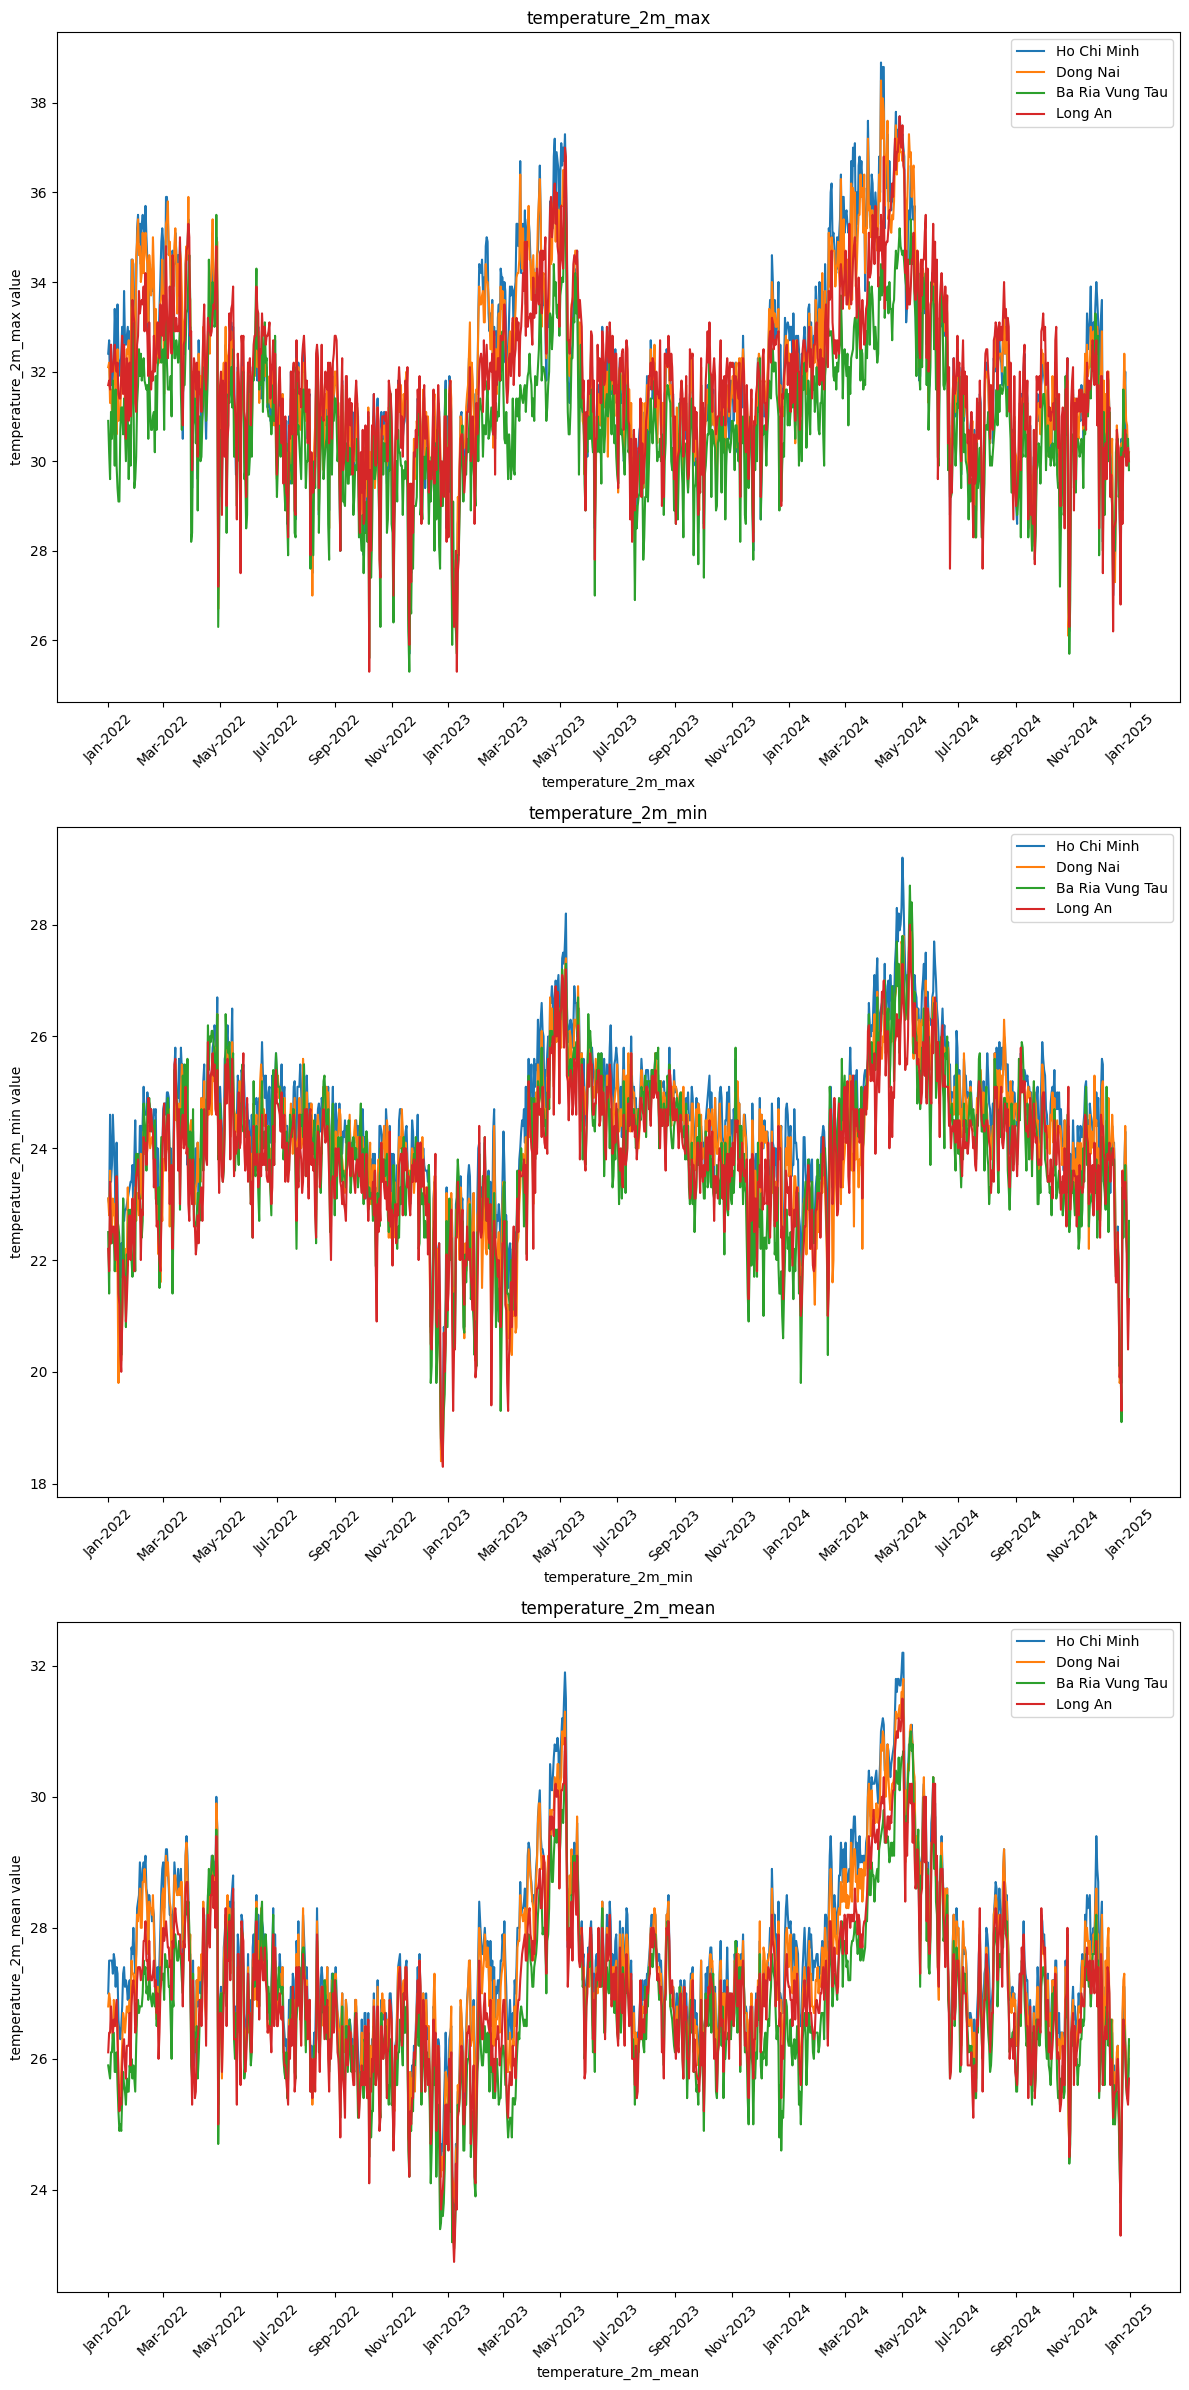

In [25]:
plot_region_data("South", south_cities, ["temperature_2m_max", "temperature_2m_min", "temperature_2m_mean"])

1. North city 

rain sum:
+ Lượng mưa dày đặc vào các tháng 5 - 10
+ Lượng mưa tăng đột biến vào năm 2024 do sự đổ bộ của cơn bão Yagi -> trường hợp đặc biệt có thể note

wind speed:
+ Trải dài đều ở mức 5-20 km/h
+ Có thể thấy ở Quảng Ninh gió to hơn các nơi khác do vùng ven biển     

relative humidity (độ ẩm):
+ Độ ẩm cao ở mức 70-90 ở các tháng mùa mưa
+ Vào các tháng mùa khô 9 - 5 có xu hướng thấp hơn so với mùa mưa

dew_point (điểm sương):
+ Thấp vào mùa khô và cao vào mùa mưa 

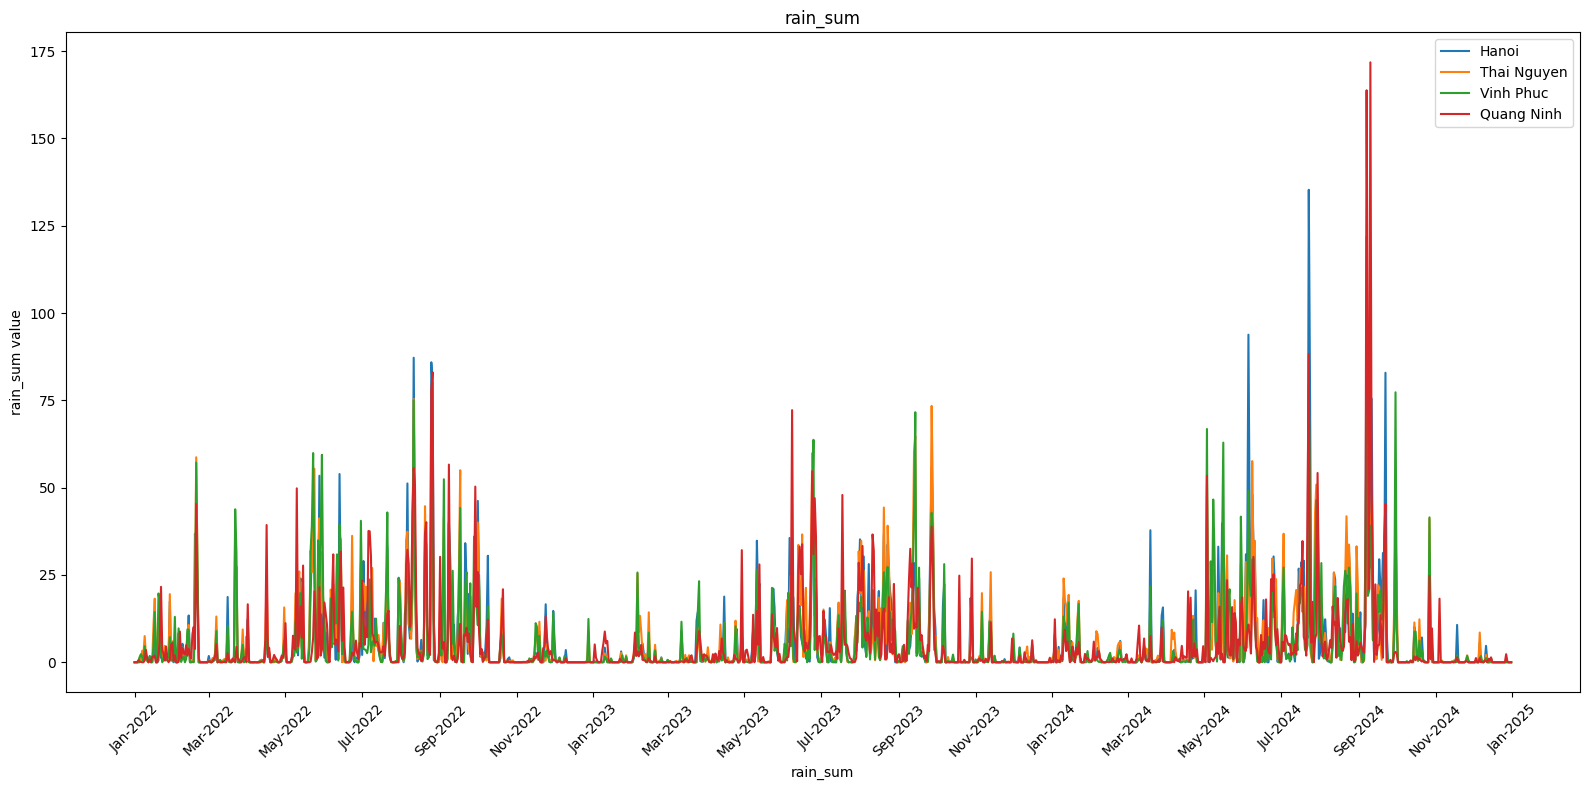

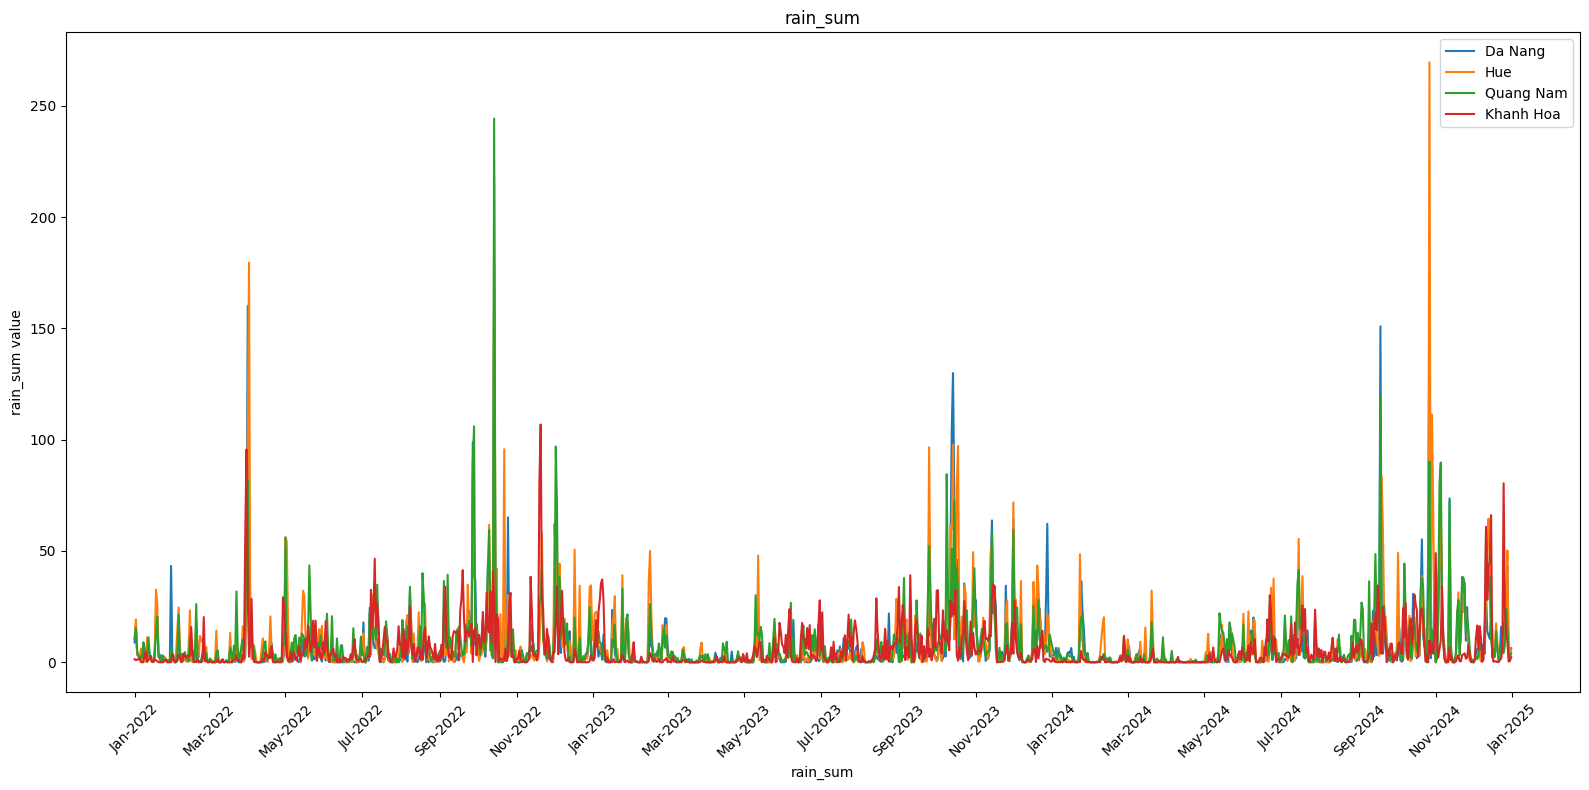

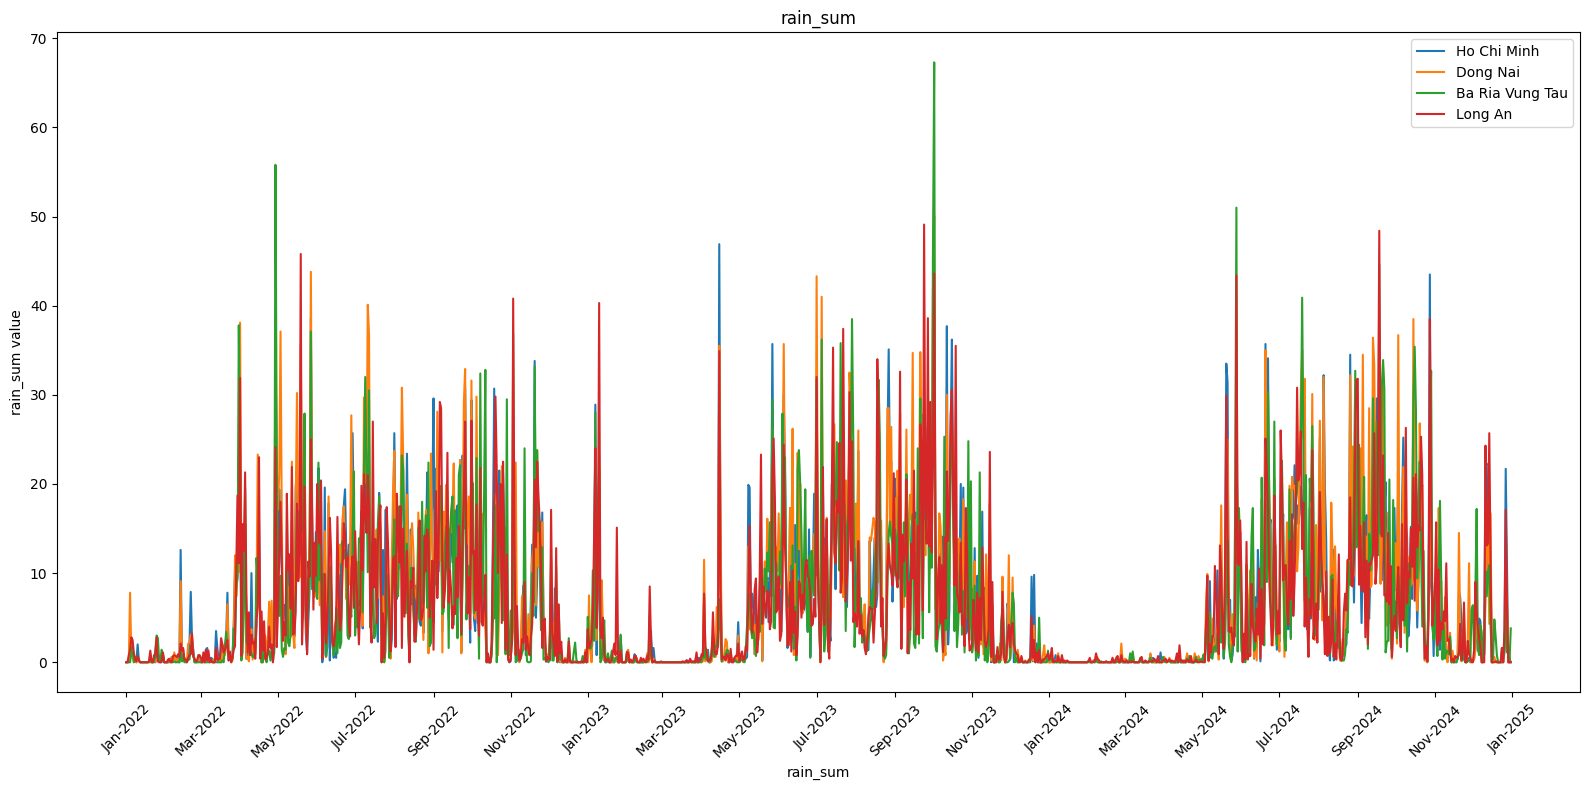

In [26]:
feature = ['rain_sum']
plot_region_data("North", north_cities, feature, fig=(16, 8))
plot_region_data("Central", central_cities, feature, fig=(16, 8))
plot_region_data("South", south_cities, feature, fig=(16, 8))

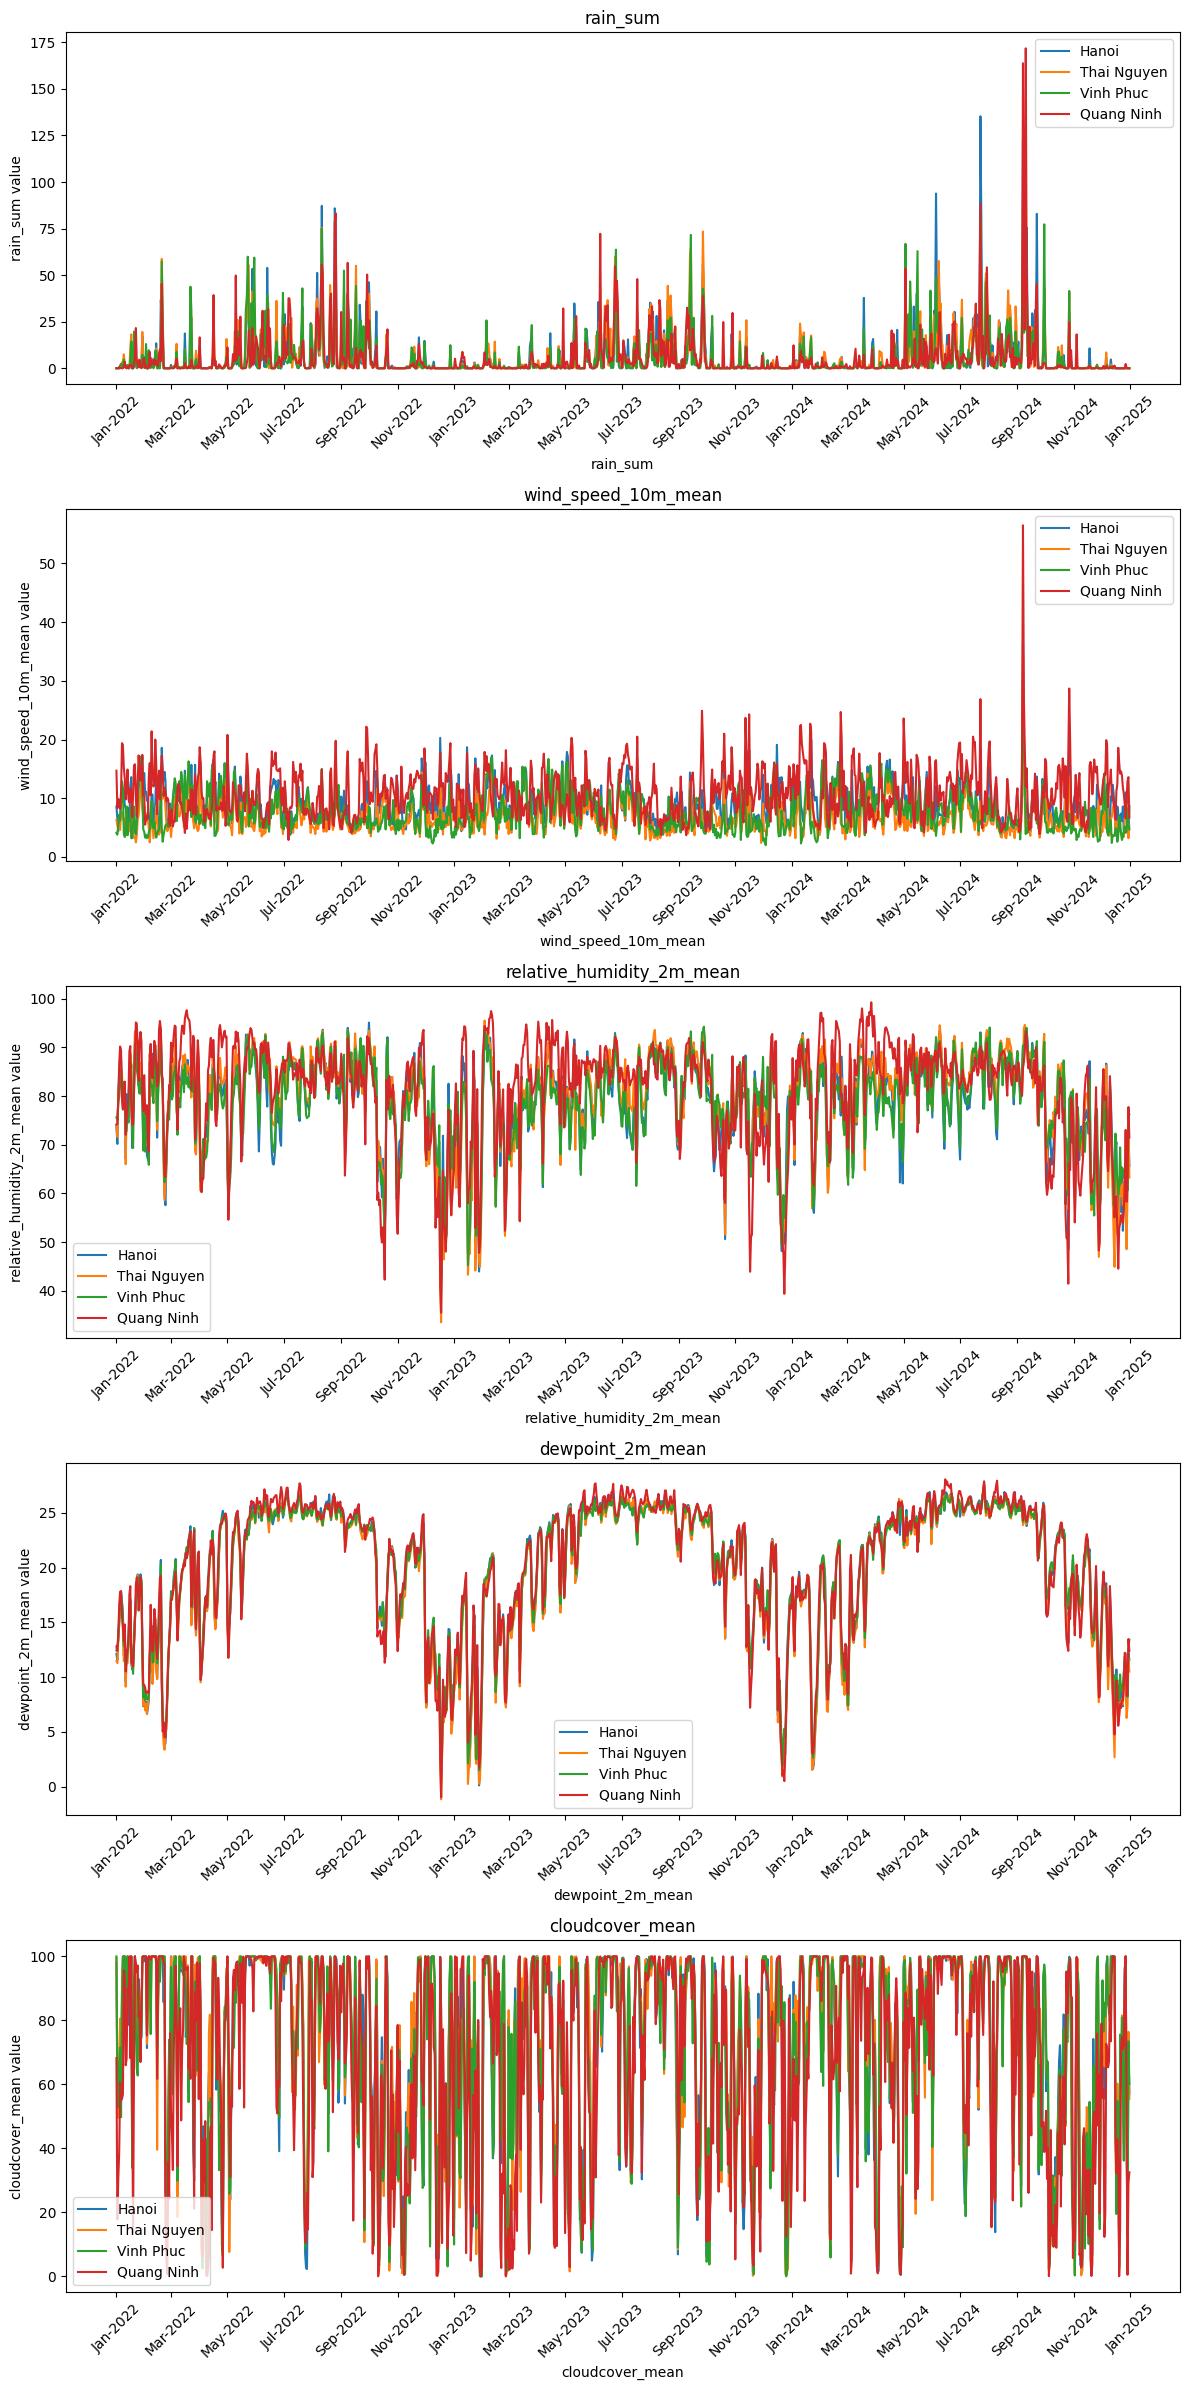

In [27]:
feature = ['rain_sum', 'wind_speed_10m_mean', 'relative_humidity_2m_mean', 'dewpoint_2m_mean', 'cloudcover_mean']
plot_region_data("North", north_cities, feature)

2. Central City 

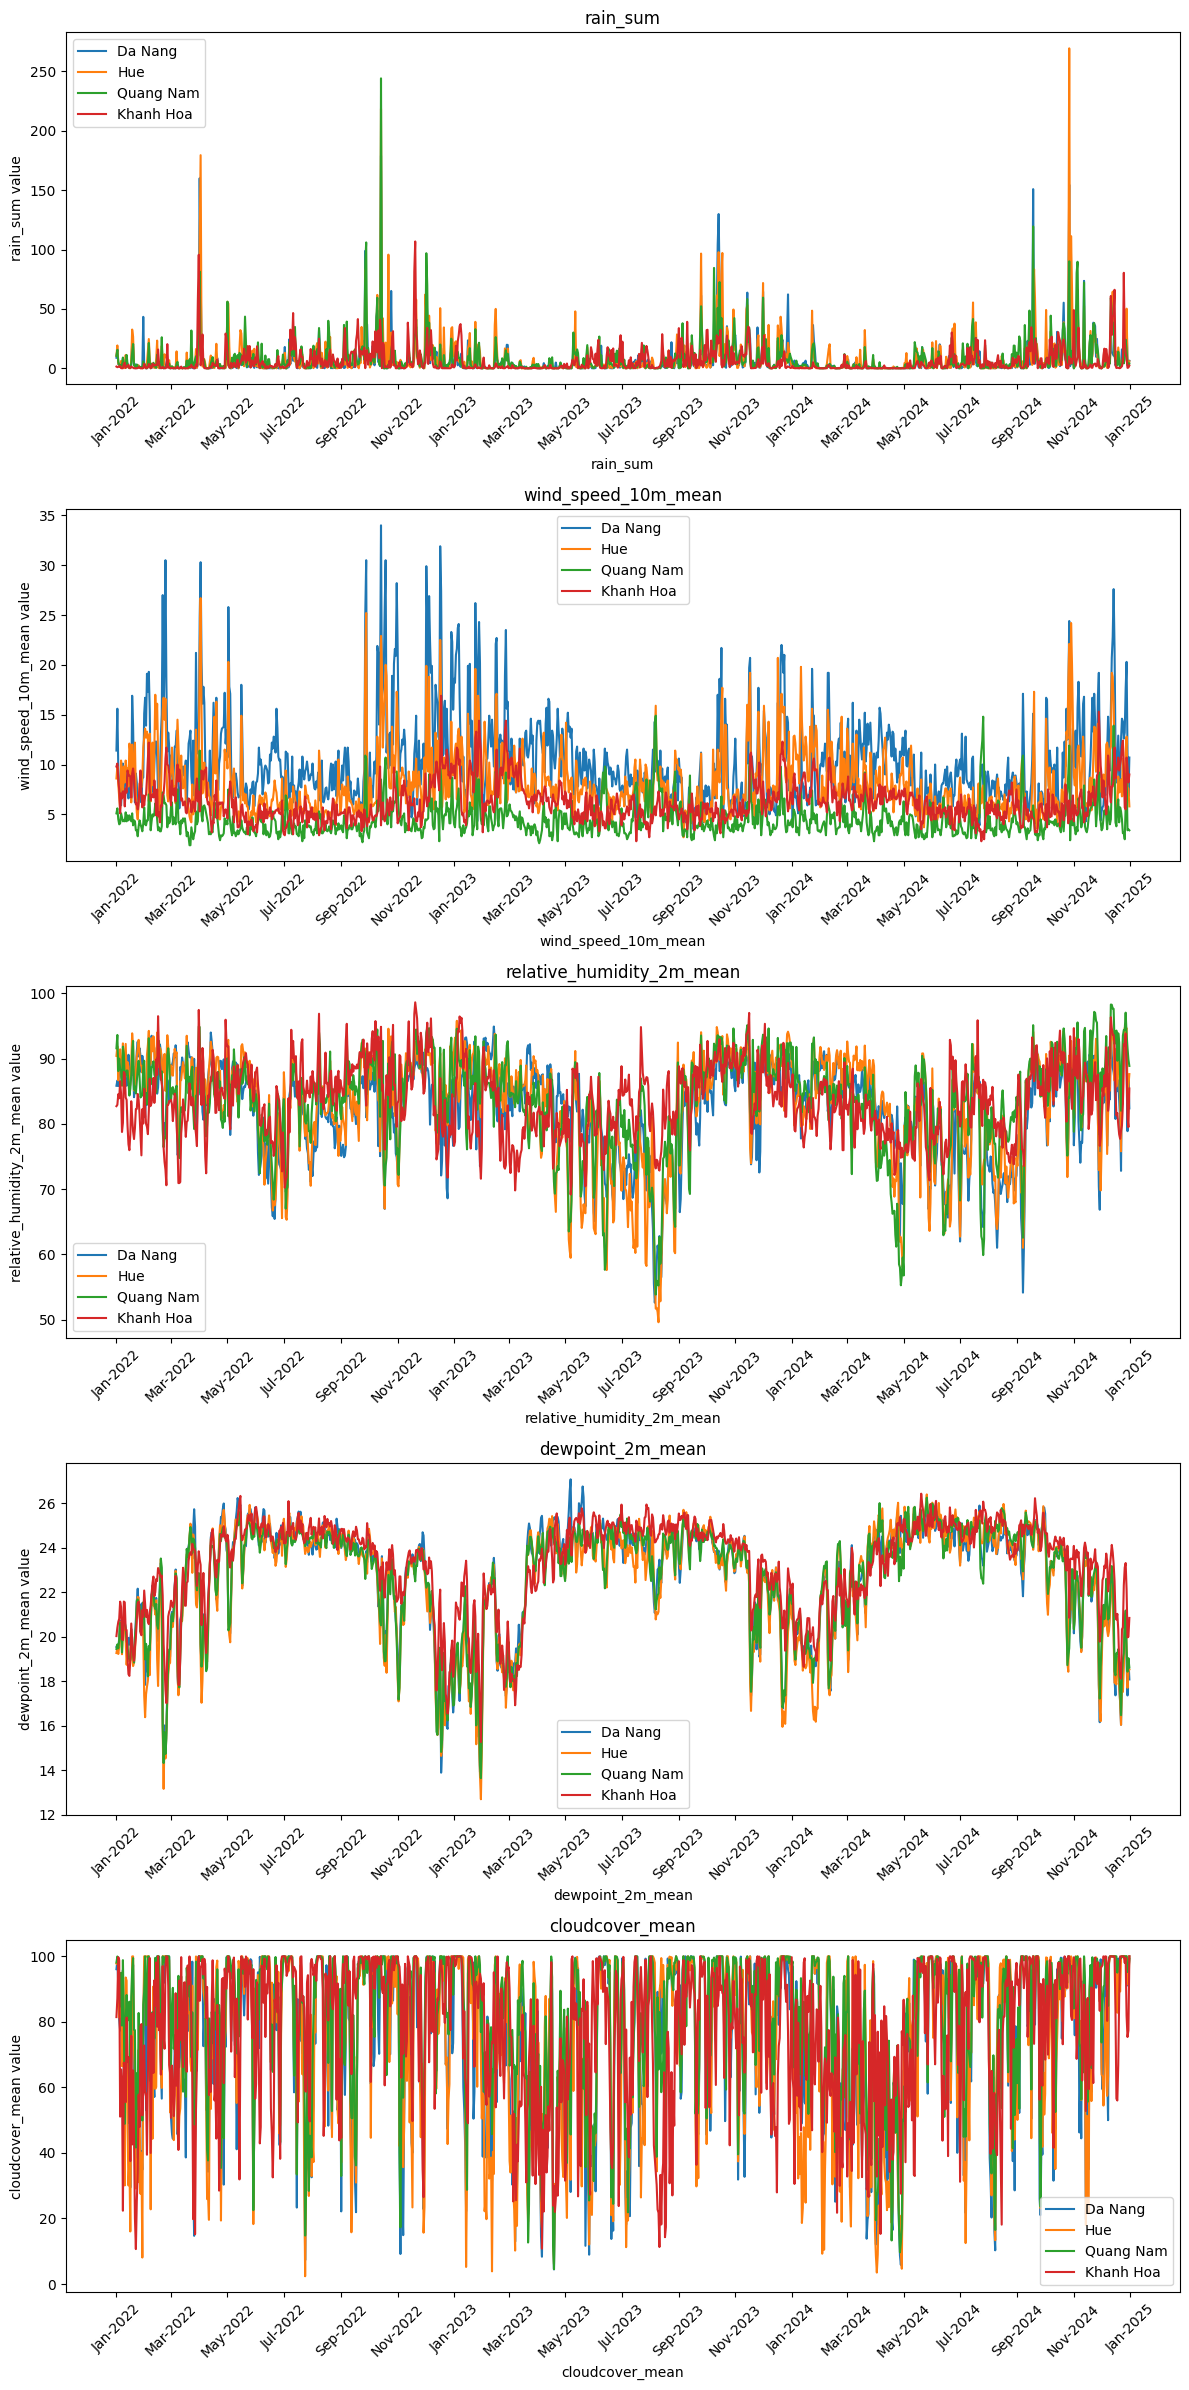

In [28]:
feature = ['rain_sum', 'wind_speed_10m_mean', 'relative_humidity_2m_mean', 'dewpoint_2m_mean', 'cloudcover_mean']
plot_region_data("Central", central_cities, feature)

3. South City

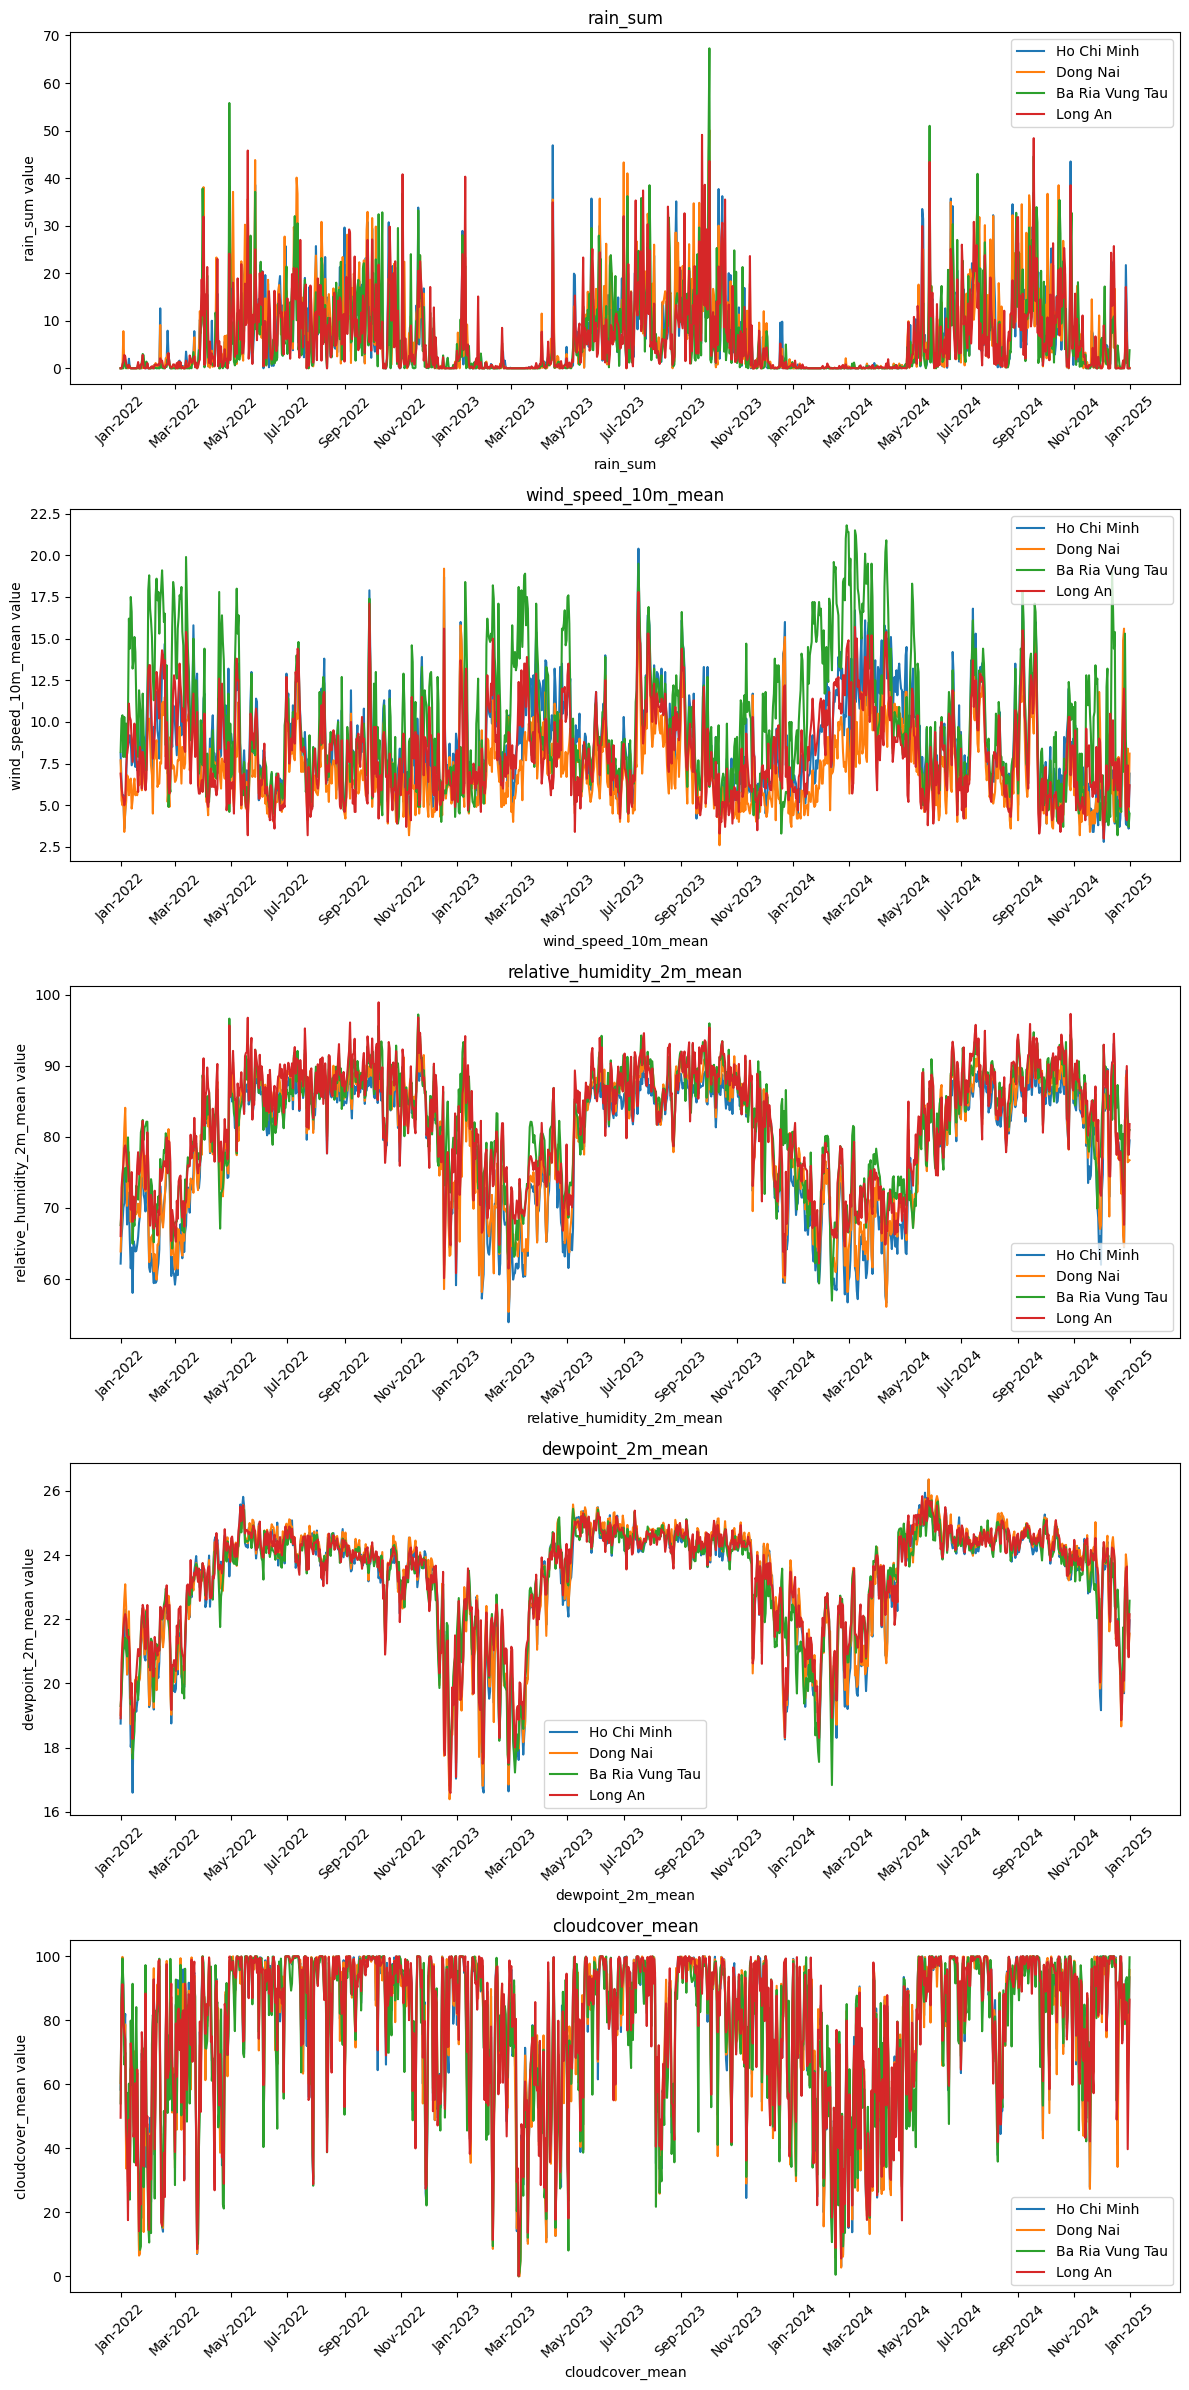

In [29]:
plot_region_data("South", south_cities, feature)

Dễ dàng thấy dewpoint và relative humidity đồng biến với các giá trị rain sum => có tác động hoặc có giá trị để predict value mưa trong khi độ che phủ của mây ko nói lên được gì 

### Histogram cho các feature theo từng vùng

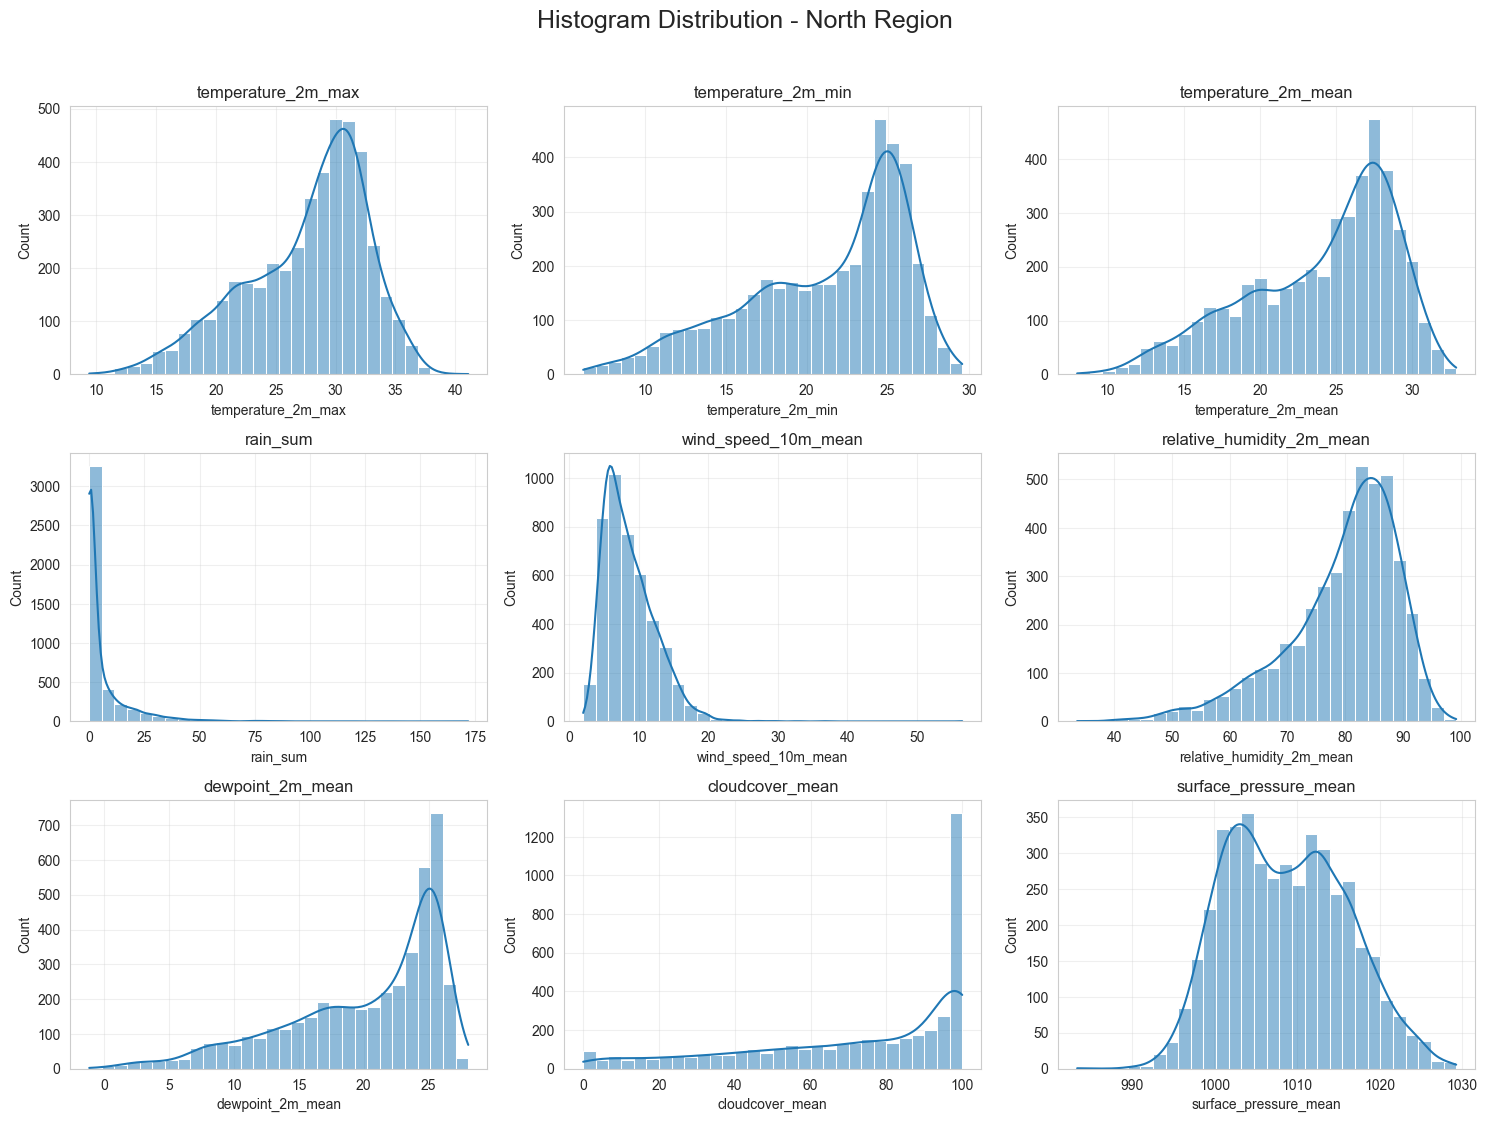

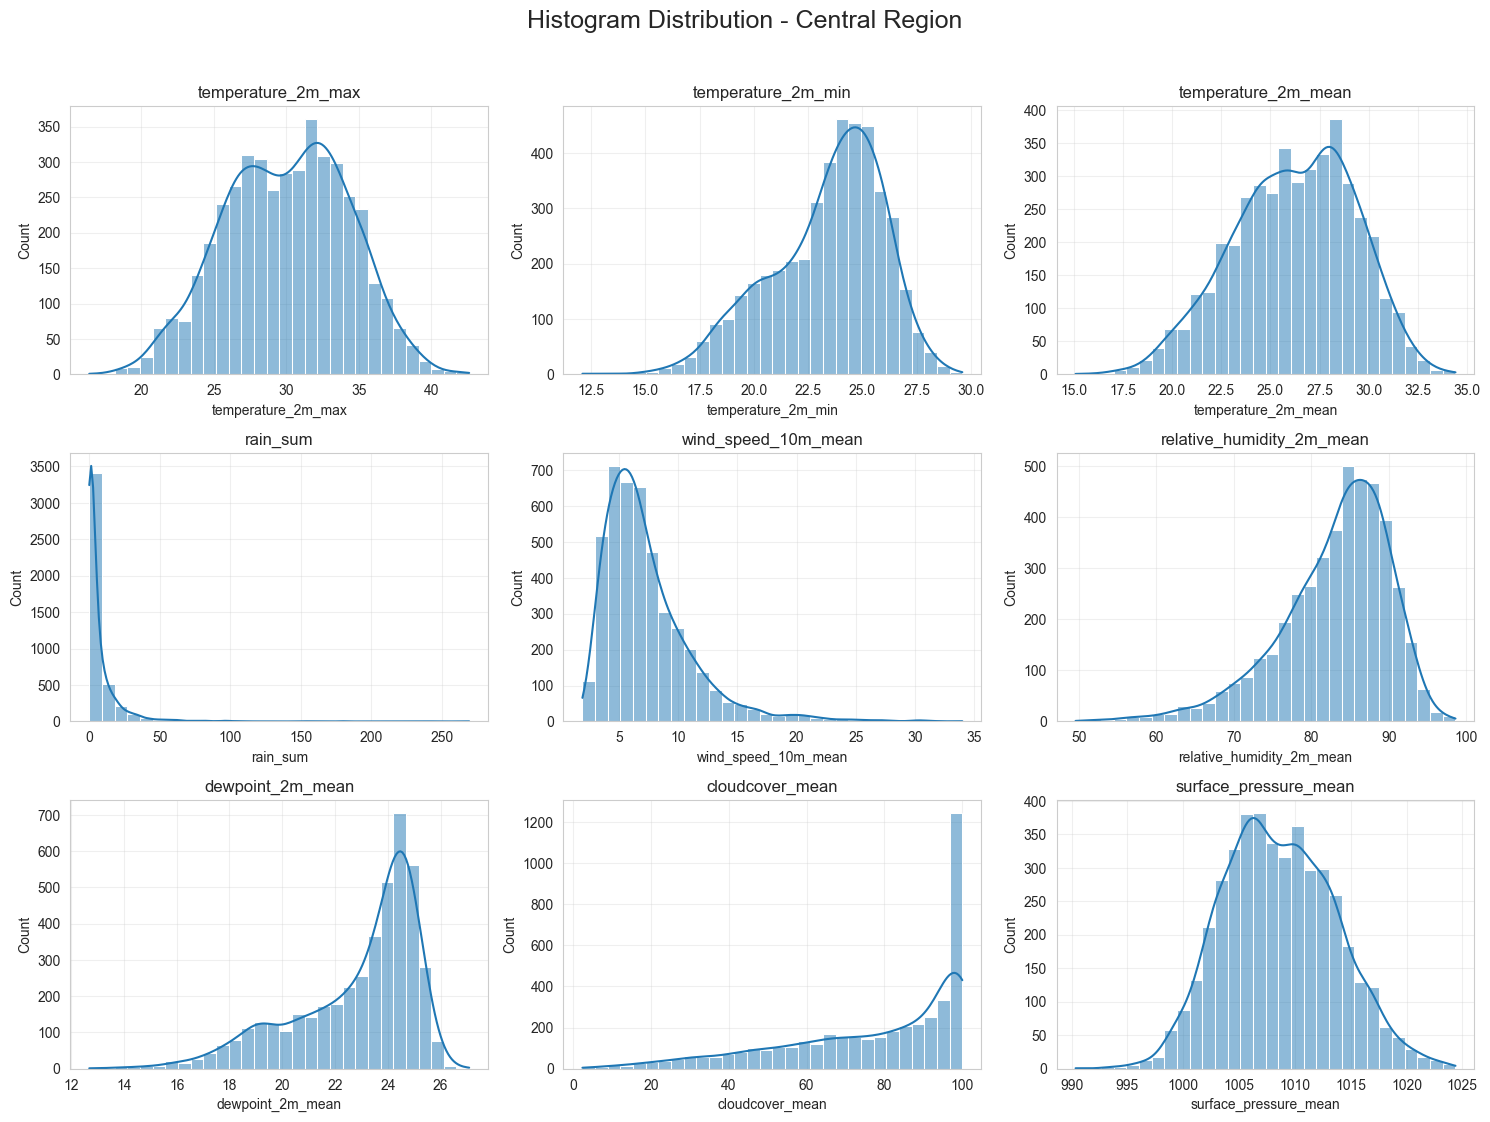

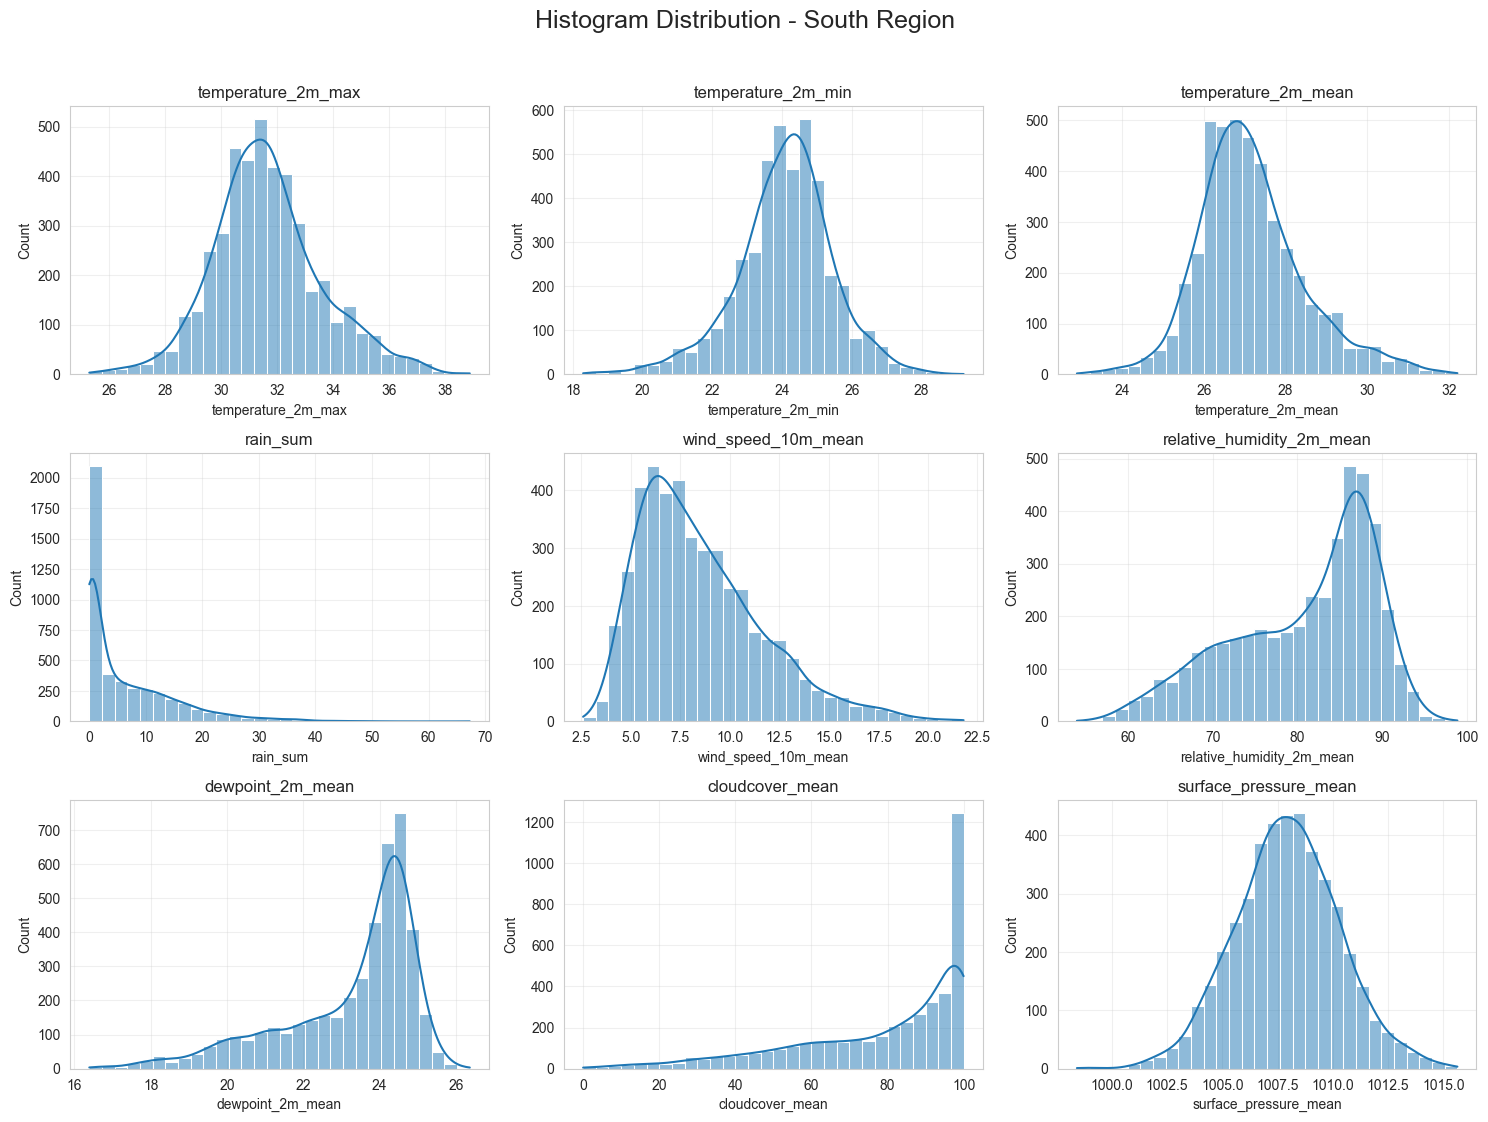

In [30]:
numeric_cols = [
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'rain_sum', 'wind_speed_10m_mean',
    'relative_humidity_2m_mean', 'dewpoint_2m_mean', 
    'cloudcover_mean', 'surface_pressure_mean'
]

import math
sns.set_style('whitegrid')

cols = 3
rows = math.ceil(len(numeric_cols) / cols)

for region_name, region_df in data_vungmien.items():
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3.8))
    fig.suptitle(f"Histogram Distribution - {region_name} Region", fontsize=18)
    axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        if col not in region_df.columns:
            ax.set_visible(False)
            continue
        data = region_df[col].dropna()
        if data.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            ax.set_title(col)
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        sns.histplot(data, kde=True, ax=ax, bins=30, color='tab:blue', edgecolor='white')
        ax.set_title(col)
        ax.grid(alpha=0.3)

    for j in range(len(numeric_cols), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


1. North Region — Histogram Distribution (Miền Bắc)

🔥 Nhiệt độ (temperature_2m_max / min / mean)

+ Phân phối hơi lệch phải nhưng khá rộng, trải từ 10°C → 35°C → thể hiện tính mùa rất mạnh (mùa đông – mùa hè).

+ Nhiệt độ trung bình dao động từ ~15°C đến ~30°C → biên độ lớn nhất trong 3 vùng.

+ Xuất hiện một số điểm nhiệt độ rất thấp (~10°C) vào mùa lạnh (Hà Nội, Thái Nguyên, Vĩnh Phúc).

🌧 Lượng mưa (rain_sum)

+ Phân phối rất lệch phải (zero-inflated): đa số ngày không mưa hoặc mưa rất ít.

+ Một vài ngày mưa lớn > 100 mm, đặc biệt là cuối hè – đầu thu.

+ Điều này đúng với khí hậu miền Bắc: mùa mưa tập trung vào tháng 5–10.

💨 Gió (wind_speed_10m_mean)

+ Phân phối hơi lệch phải, chủ yếu ở mức 5–15 m/s.

+ Có một số giá trị gió mạnh hơn (>25 m/s), thường đến từ Quảng Ninh (ảnh hưởng ven biển).

💧 Độ ẩm (relative_humidity_2m_mean)

+ Phân phối rất cao, chủ yếu nằm trong khoảng 70–95%.

+ Điều này phản ánh đặc trưng thời tiết miền Bắc:

+ Mùa nồm, ẩm ướt

+ Mùa mưa kéo dài và nhiều ngày âm u

🌫 Dewpoint (dewpoint_2m_mean)

+ Đa phần nằm trong 15–25°C, tăng mạnh ở mùa mưa.

+ Khi dewpoint cao (~25°C), không khí thường oi bức, khó chịu.

☁ Cloudcover_mean

+ Rất nhiều ngày có giá trị lên 90–100%, nghĩa là trời nhiều mây.

+ Điều này phù hợp với thời tiết miền Bắc vốn nhiều ngày âm u và mưa phùn.

⬆ Áp suất (surface_pressure_mean)

+ Phân phối hai đỉnh (bimodal): khoảng 1005–1018 hPa.

+ Có thể do chu kỳ giữa mùa đông (áp cao lạnh) và mùa hè (áp thấp nóng).

2. Central Region — Histogram Distribution (Miền Trung)

🔥 Nhiệt độ

 Phân phối dịch sang phải so với miền Bắc:

+ Max: 28–38°C

+ Mean: ~25–32°C

+ Ít giá trị thấp (<20°C), đúng với đặc trưng nóng quanh năm.

🌧 Lượng mưa (rain_sum)

+ Phân phối rất lệch phải, với một số ngày mưa cực lớn:

+ Có điểm lên đến 200–250 mm

+ Đây là dấu hiệu của mưa lũ miền Trung, thường vào tháng 9–12.

💨 Gió (wind_speed_10m_mean)

+ Gió mạnh hơn miền Bắc và Nam vào mùa bão.

+ Phân phối tập trung ở 5–15 m/s với đuôi phải dài hơn.

💧 Độ ẩm (relative humidity)

+ Rất cao, phần lớn 75–95%, tương tự miền Bắc nhưng với mức thấp hơn vào mùa khô.

🌫 Dewpoint

+ Dao động chủ yếu trong 20–26°C, khá đồng đều → phản ánh khí hậu nóng ẩm.

☁ Cloudcover

+ Rất nhiều ngày có cloudcover lên 100%, đặc biệt mùa mưa bão.

⬆ Áp suất (surface_pressure_mean)

+ Miền Trung có phân phối tập trung quanh 1008–1016 hPa.

+ Nhìn chung ít dao động hơn miền Bắc.

South Region — Histogram Distribution (Miền Nam)

🔥 Nhiệt độ

+ Phân phối hẹp và cao hơn 2 vùng còn lại:

+ Max: 30–36°C

+ Mean: 26–30°C

+ Không có mùa đông → data gần chuẩn (Gaussian-like).

🌧 Lượng mưa (rain_sum)

+ Lệch phải giống các vùng nhưng ít cực đoan hơn miền Trung.

+ Mưa rào nhiệt đới, phổ biến mưa 10–30 mm, ít khi vượt 60 mm.

💨 Gió (wind_speed_10m_mean)

+ Gió nhẹ nhất trong 3 miền, thường chỉ 3–10 m/s.

+ Miền Nam ít chịu ảnh hưởng bão trực tiếp.

💧 Độ ẩm (relative humidity)

+ Cao ổn định, 70–95%, gần giống miền Bắc nhưng ít biến động.

🌫 Dewpoint

+ Cao nhất trong 3 miền: 22–26°C, thể hiện khí hậu nóng ẩm quanh năm.

+ Khi dewpoint cao → dễ có mưa dông buổi chiều.

☁ Cloudcover

+ Nhiều ngày trời nhiều mây nhưng ít hơn miền Bắc/Trung.

⬆ Áp suất

+ Tập trung mạnh ở 1007–1012 hPa, rất ổn định.

+ Miền Nam ít bị ảnh hưởng bởi các hệ thống áp thấp/bão.

Miền Bắc

+ Biên độ nhiệt rộng nhất

+ Độ ẩm và mây cao

+ Mưa tập trung vào mùa hè – đầu thu

Miền Trung

+ Nóng quanh năm

+ Mưa cực đoan, mùa bão mạnh

+ Gió mạnh vào mùa mưa bão

Miền Nam

+ Nhiệt độ ổn định nhất

+ Mưa rào nhiệt đới, ít cực đoan

+ Gió nhẹ

### KDE so sánh 3 vùng

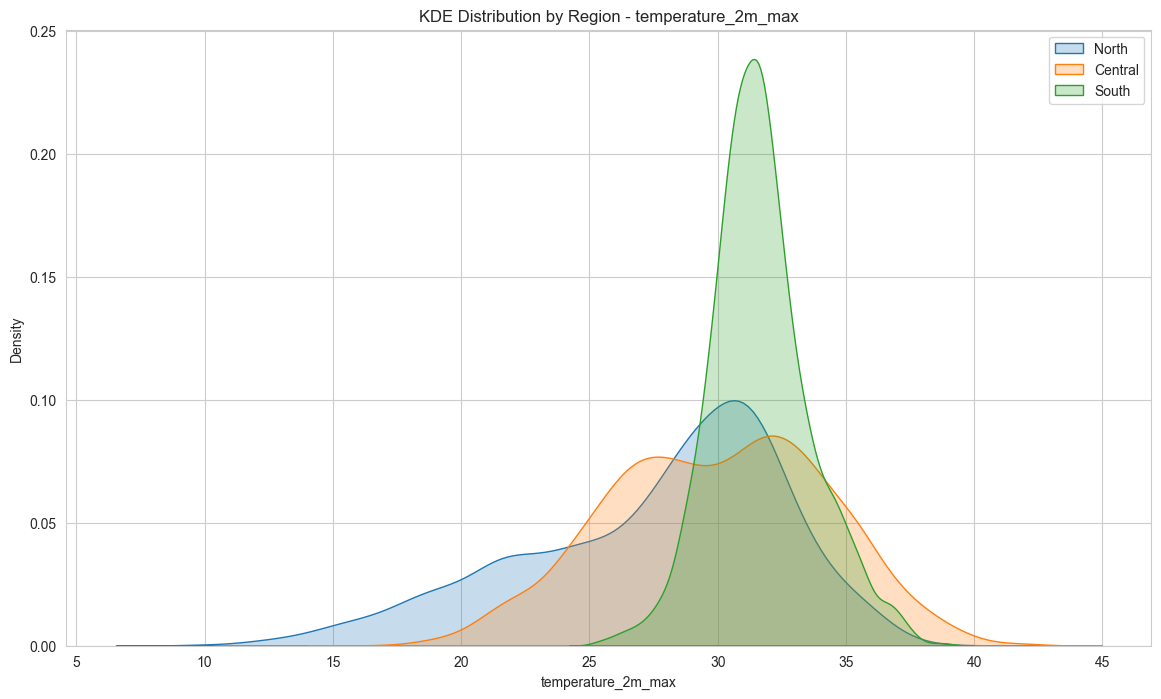

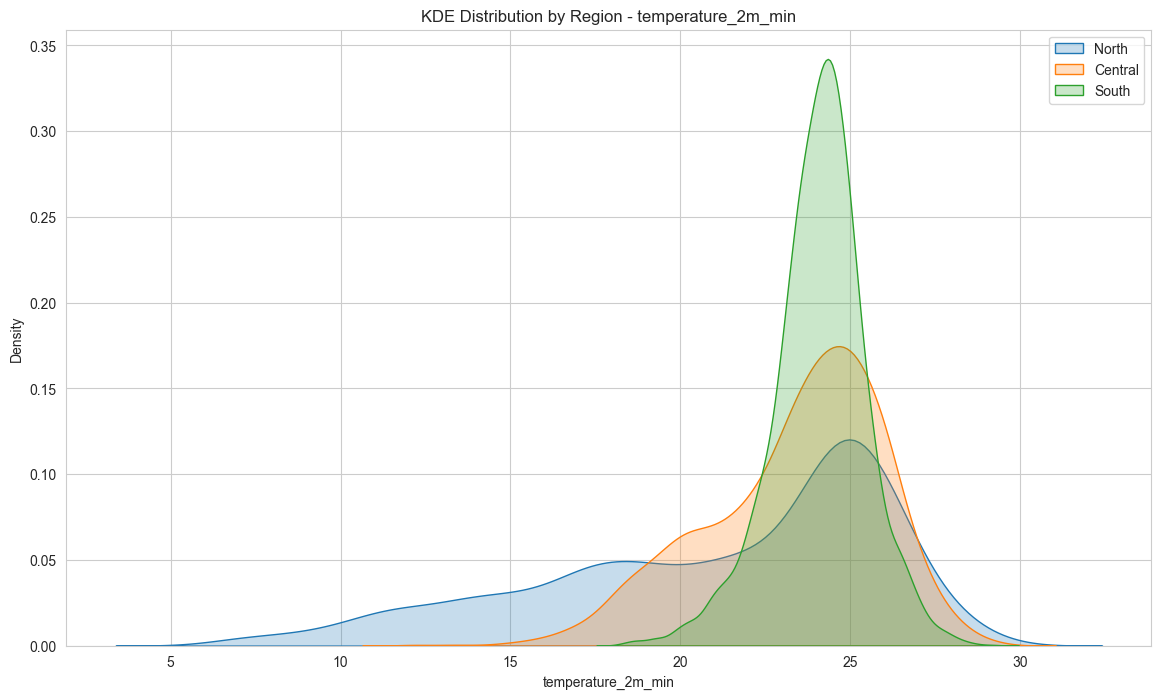

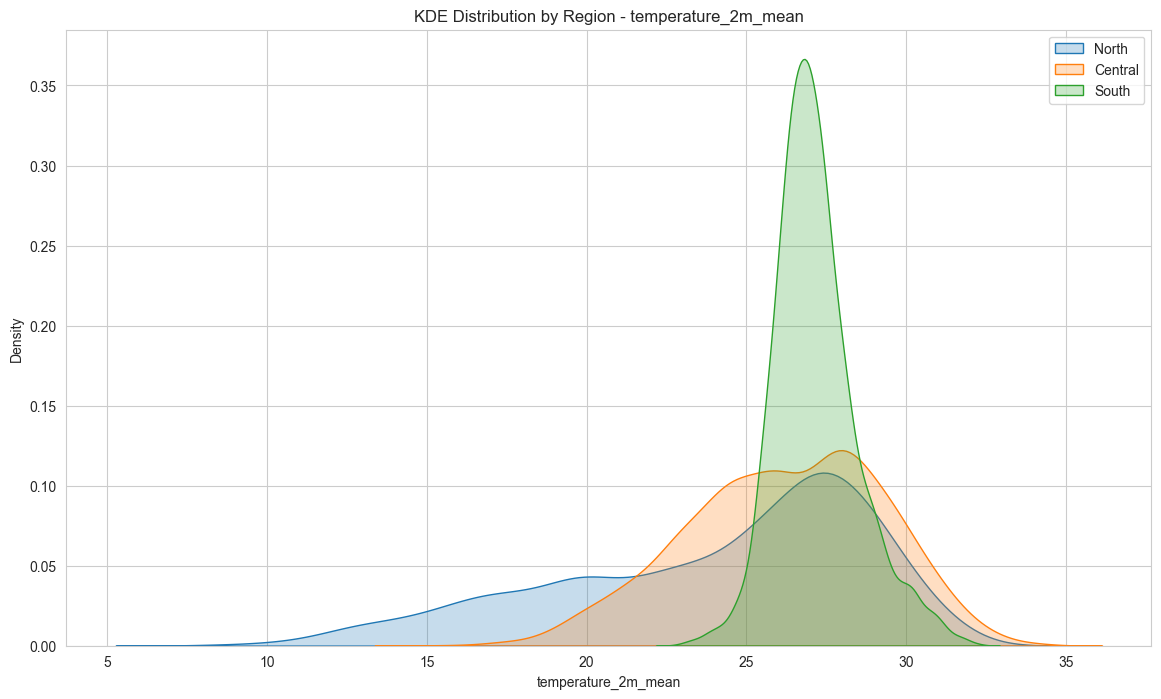

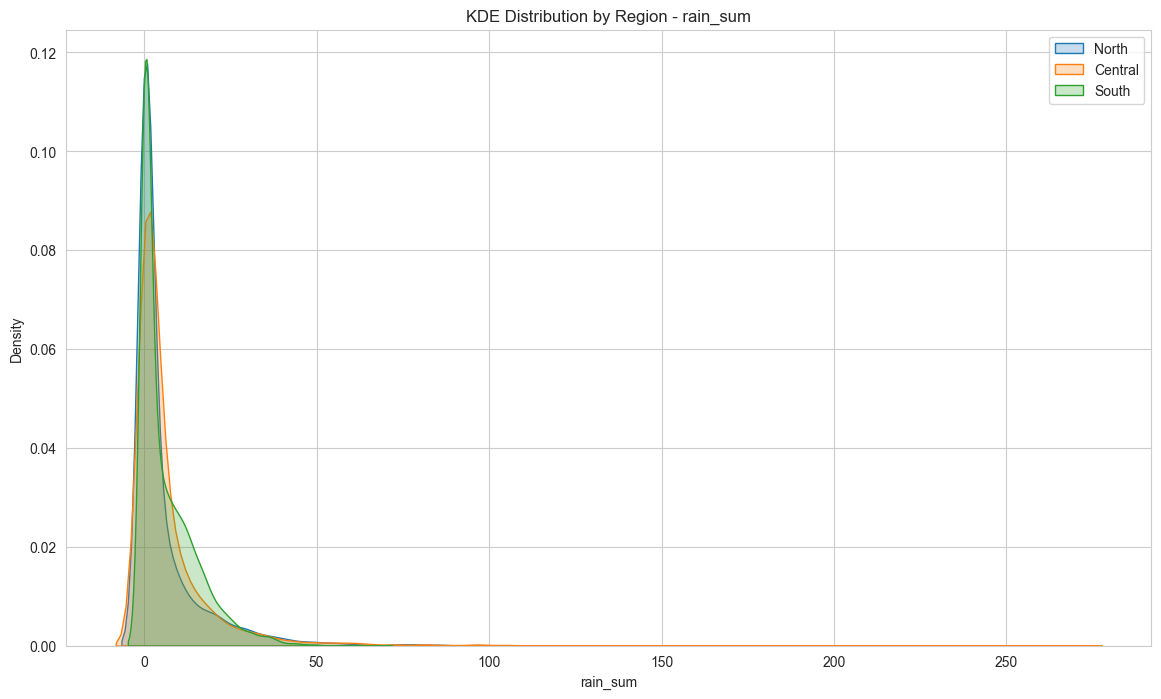

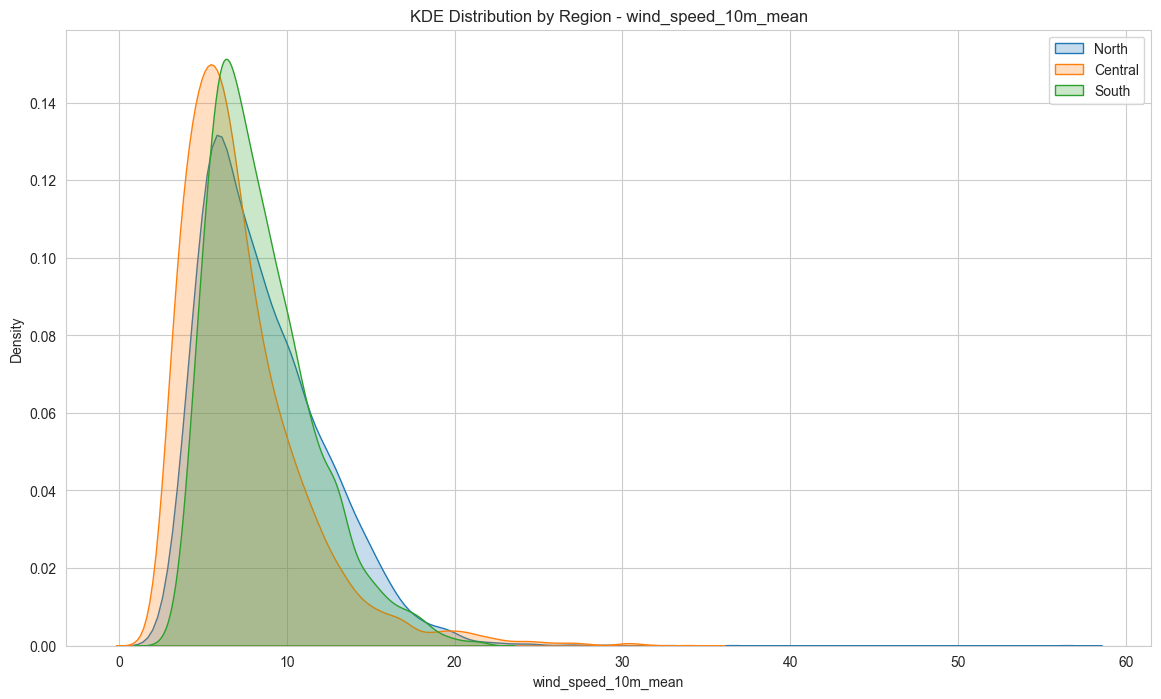

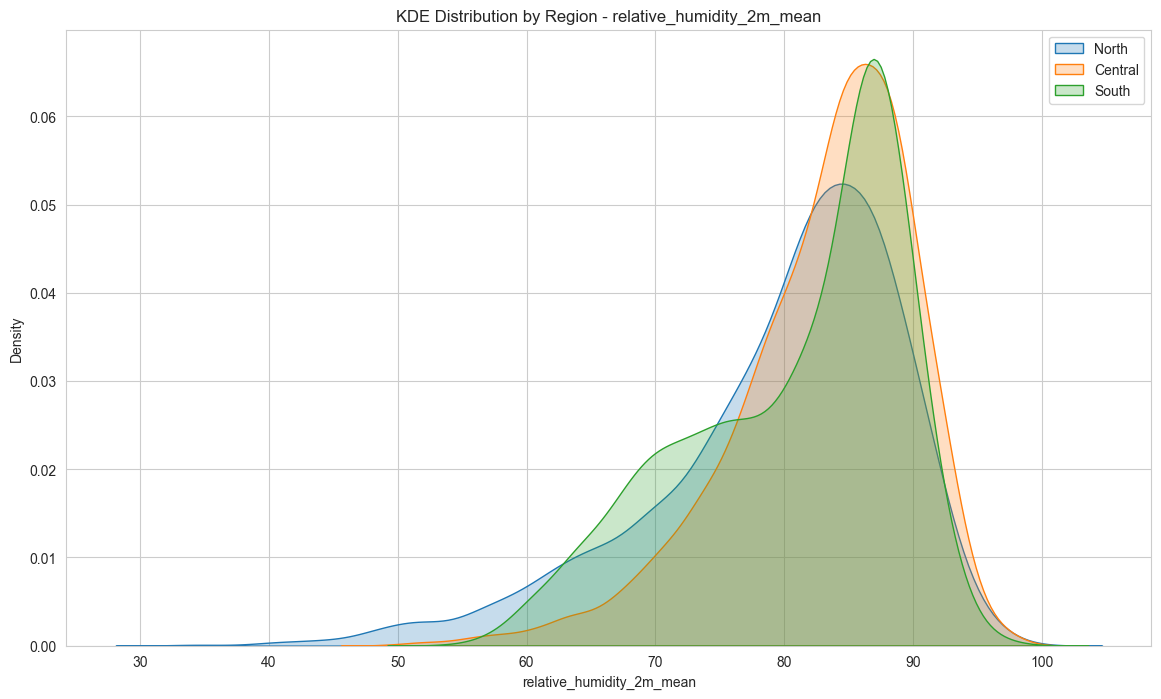

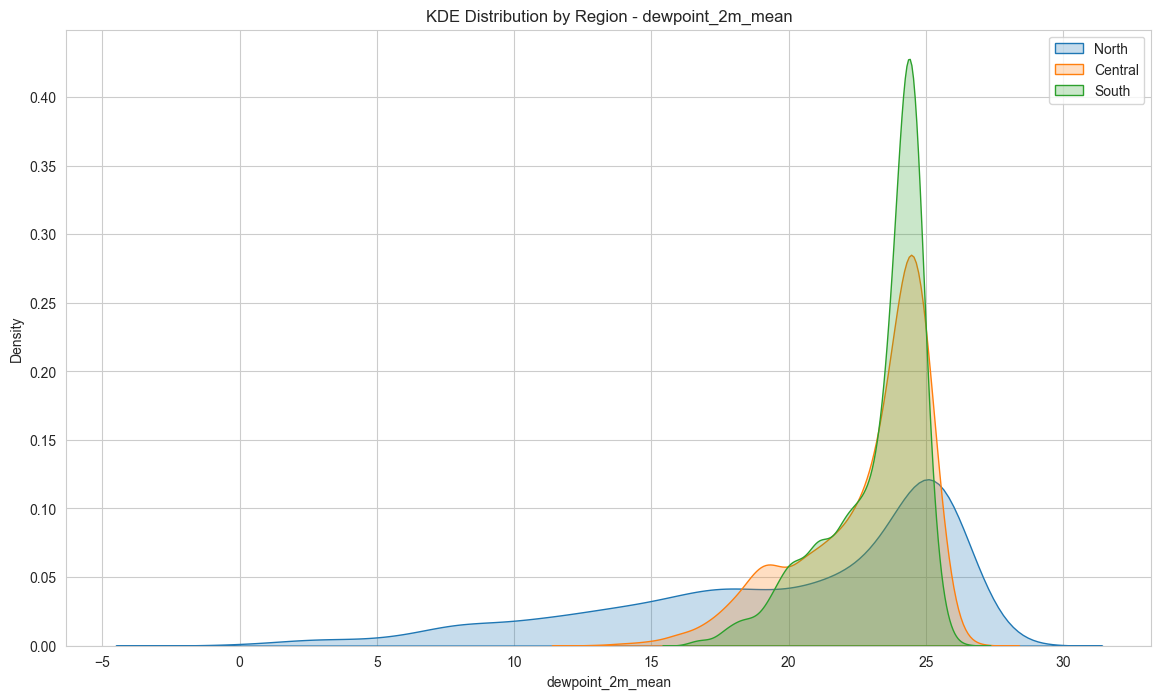

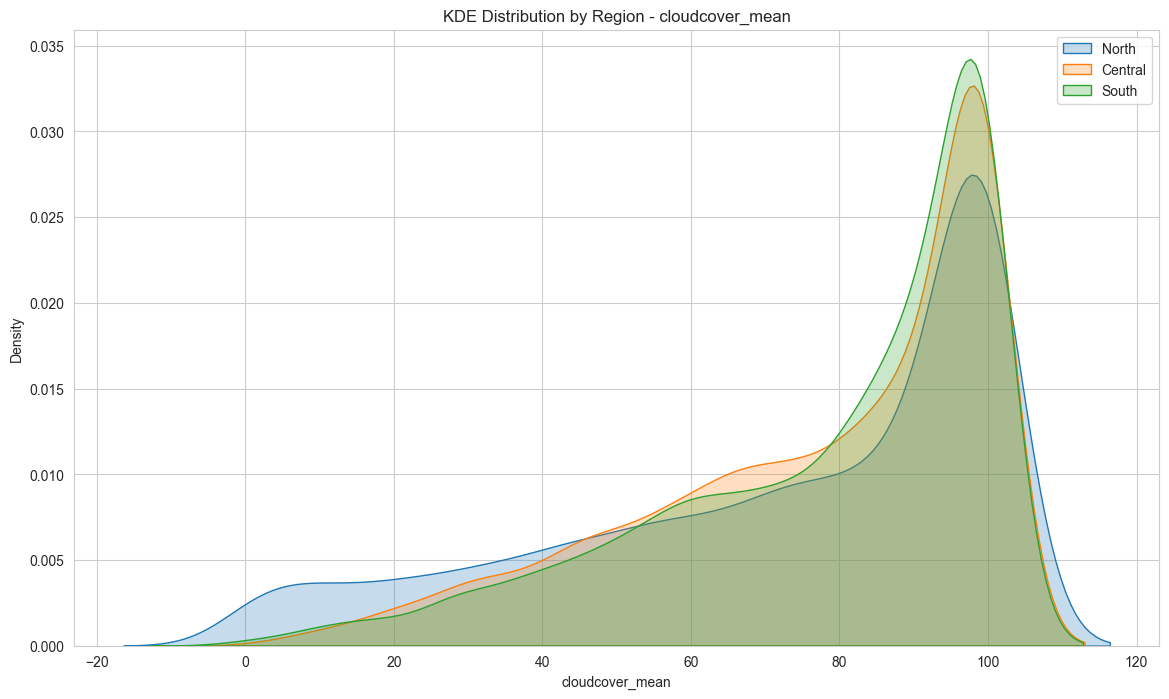

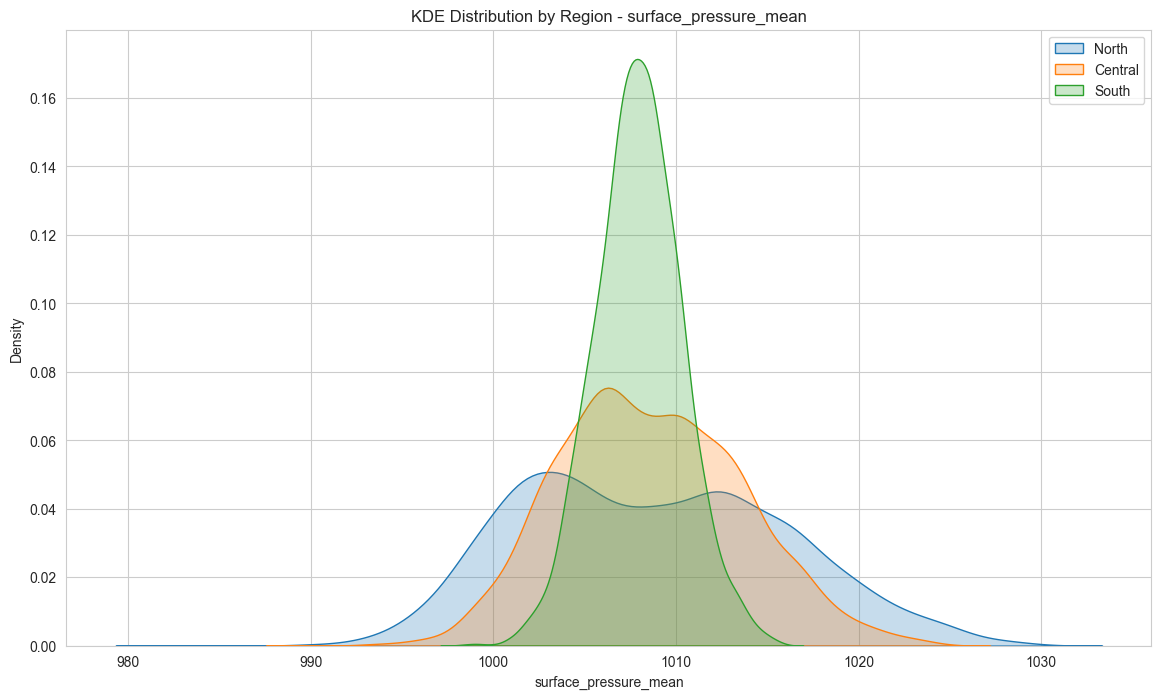

In [40]:
for col in numeric_cols:
    plt.figure(figsize=(14,8))
    sns.kdeplot(data=data_vungmien['North'], x=col, label='North', fill=True, alpha=0.25)
    sns.kdeplot(data=data_vungmien['Central'], x=col, label='Central', fill=True, alpha=0.25)
    sns.kdeplot(data=data_vungmien['South'], x=col, label='South', fill=True, alpha=0.25)
    plt.title(f"KDE Distribution by Region - {col}")
    plt.legend()
    plt.show()

✔ Miền Bắc: phân phối feature rộng, biến thiên theo mùa → khó dự báo nhất

✔ Miền Trung: nhiệt độ cao, mưa cực đoan, dewpoint & humidity cao → bão & mưa lớn chi phối

✔ Miền Nam: các đường KDE rất hẹp → dễ dự báo, khí hậu ổn định

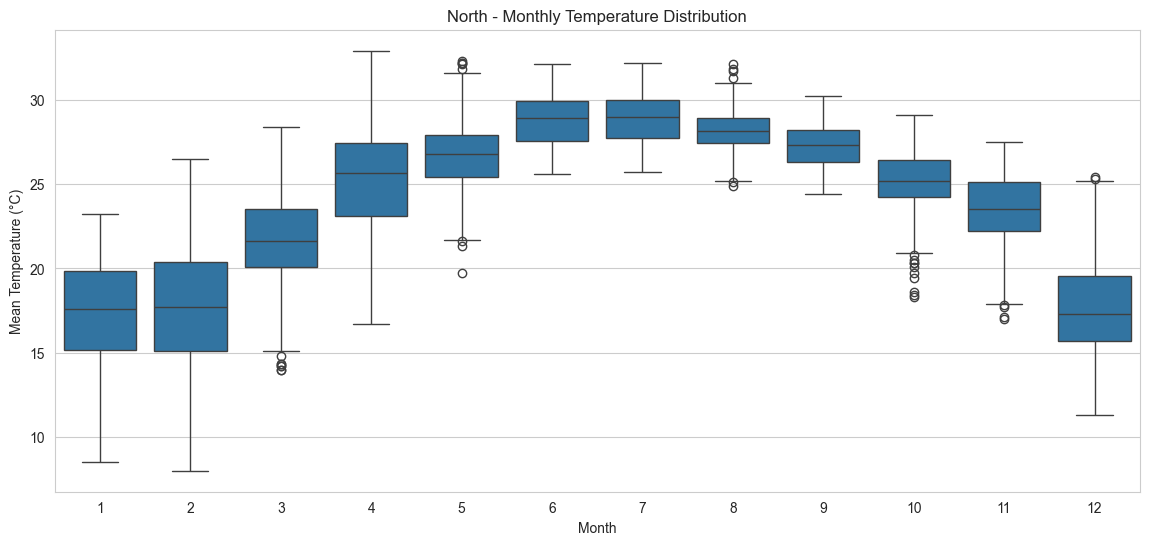

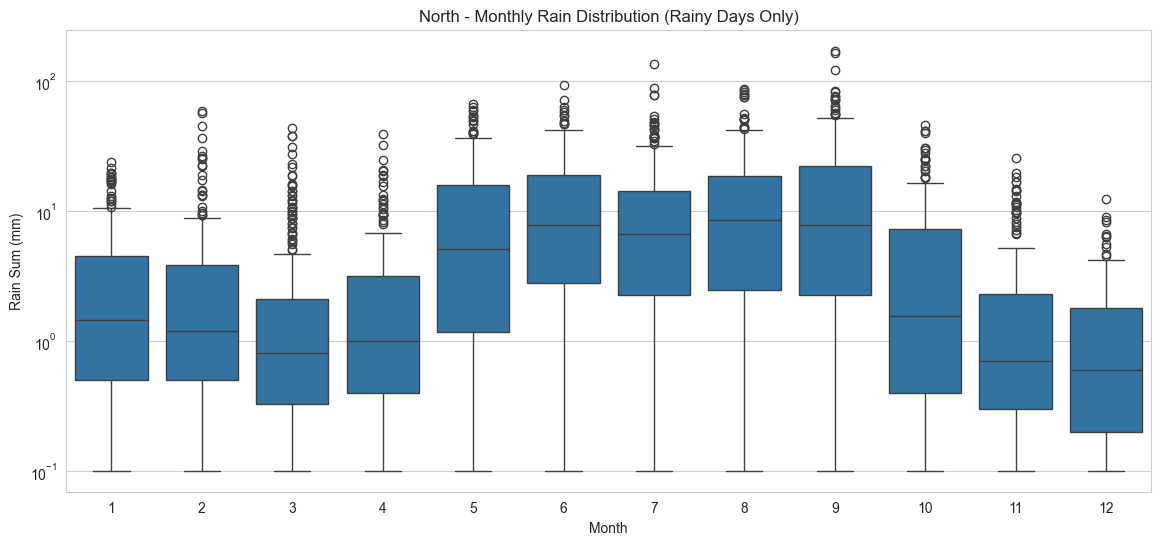

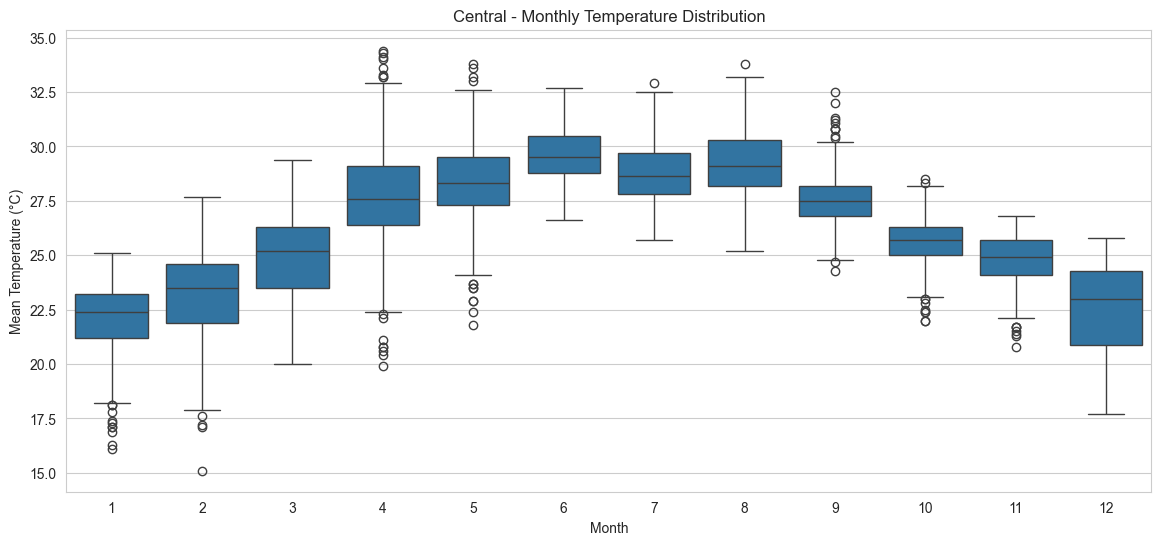

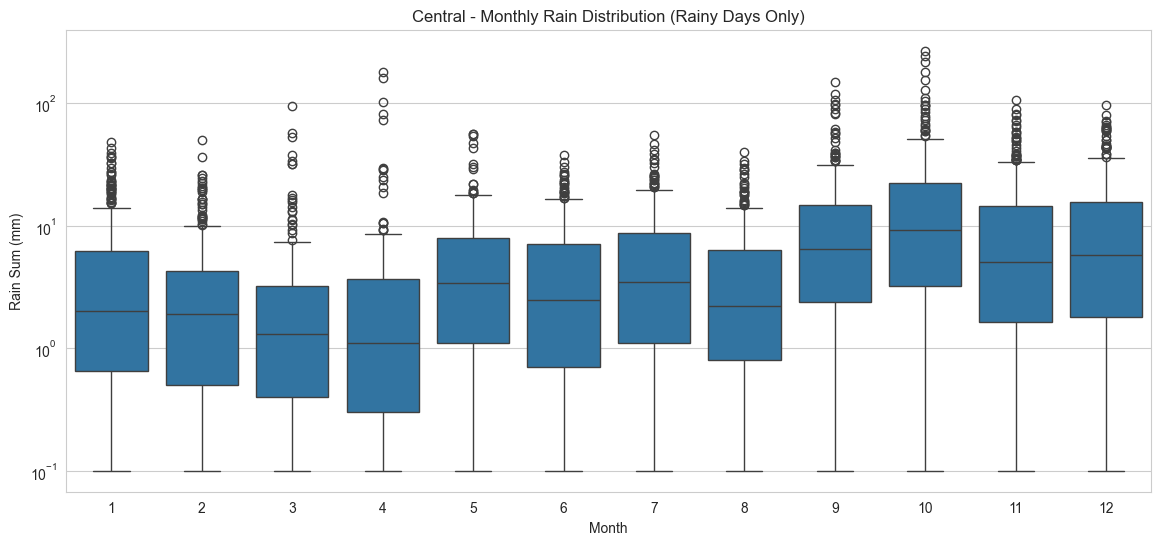

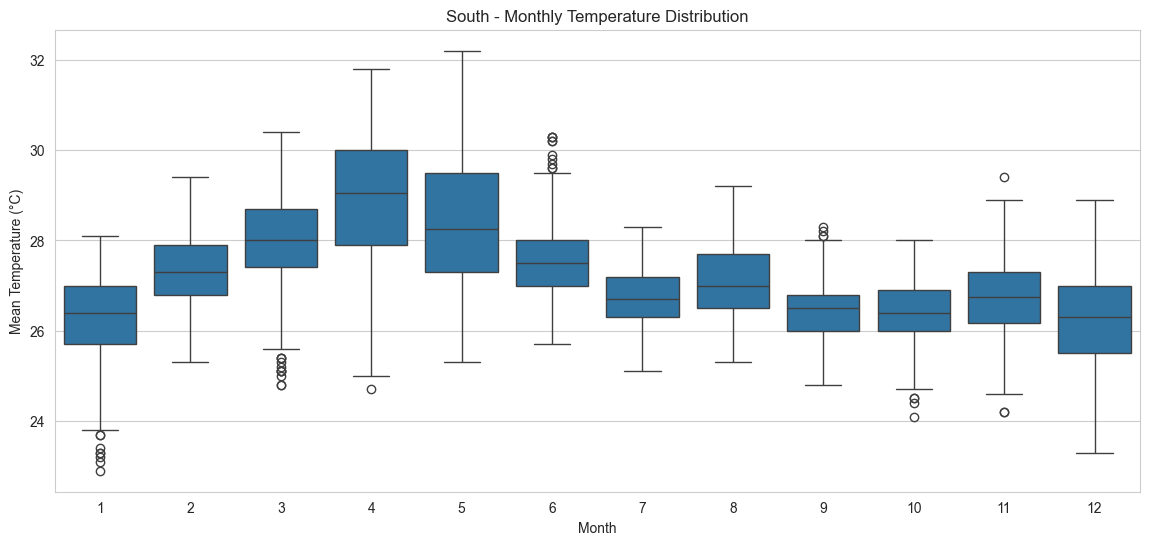

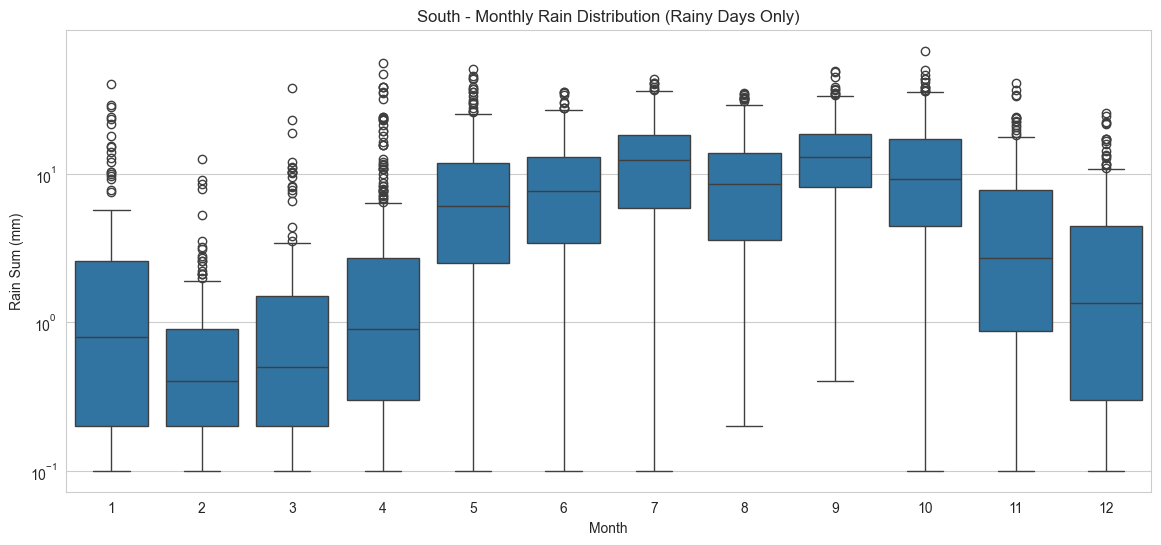

In [ ]:
df['month'] = pd.to_datetime(df['date']).dt.month

for region_name, region_df in data_vungmien.items():
    region_df = region_df.copy()
    if 'month' not in region_df.columns:
        region_df['month'] = pd.to_datetime(region_df['date']).dt.month

    plt.figure(figsize=(14,6))
    sns.boxplot(data=region_df, x='month', y='temperature_2m_mean')
    plt.title(f"{region_name} - Monthly Temperature Distribution")
    plt.xlabel('Month')
    plt.ylabel('Mean Temperature (°C)')
    plt.show()

    rainy = region_df[region_df['rain_sum'] > 0].copy()
    if not rainy.empty:
        plt.figure(figsize=(14,6))
        sns.boxplot(data=rainy, x='month', y='rain_sum')
        plt.yscale('log')
        plt.title(f"{region_name} - Monthly Rain Distribution (Rainy Days Only)")
        plt.xlabel('Month')
        plt.ylabel('Rain Sum (mm)')
        plt.show()
    else:
        print(f"No rainy days for {region_name} - skipping rain boxplot")

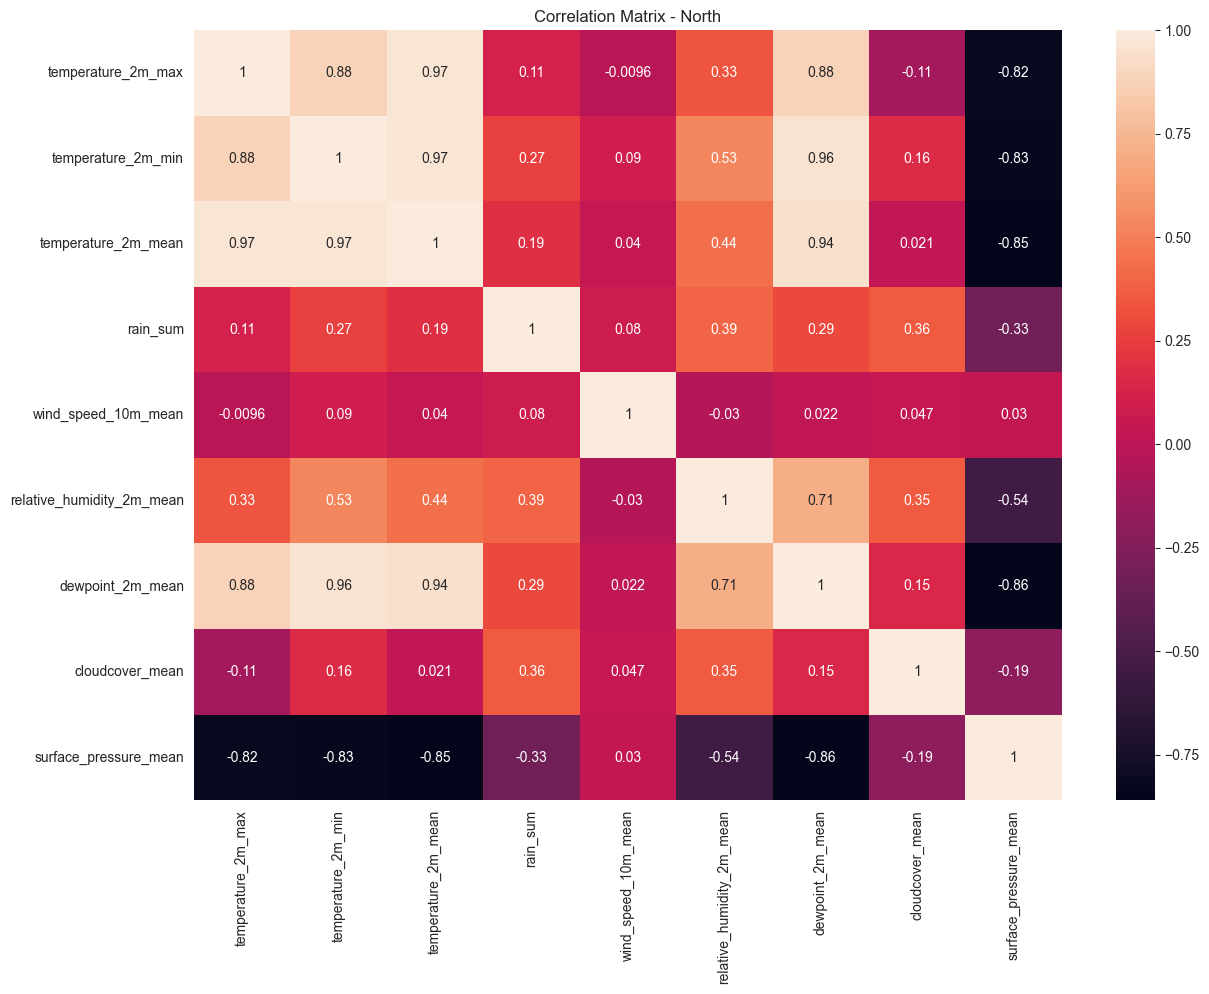

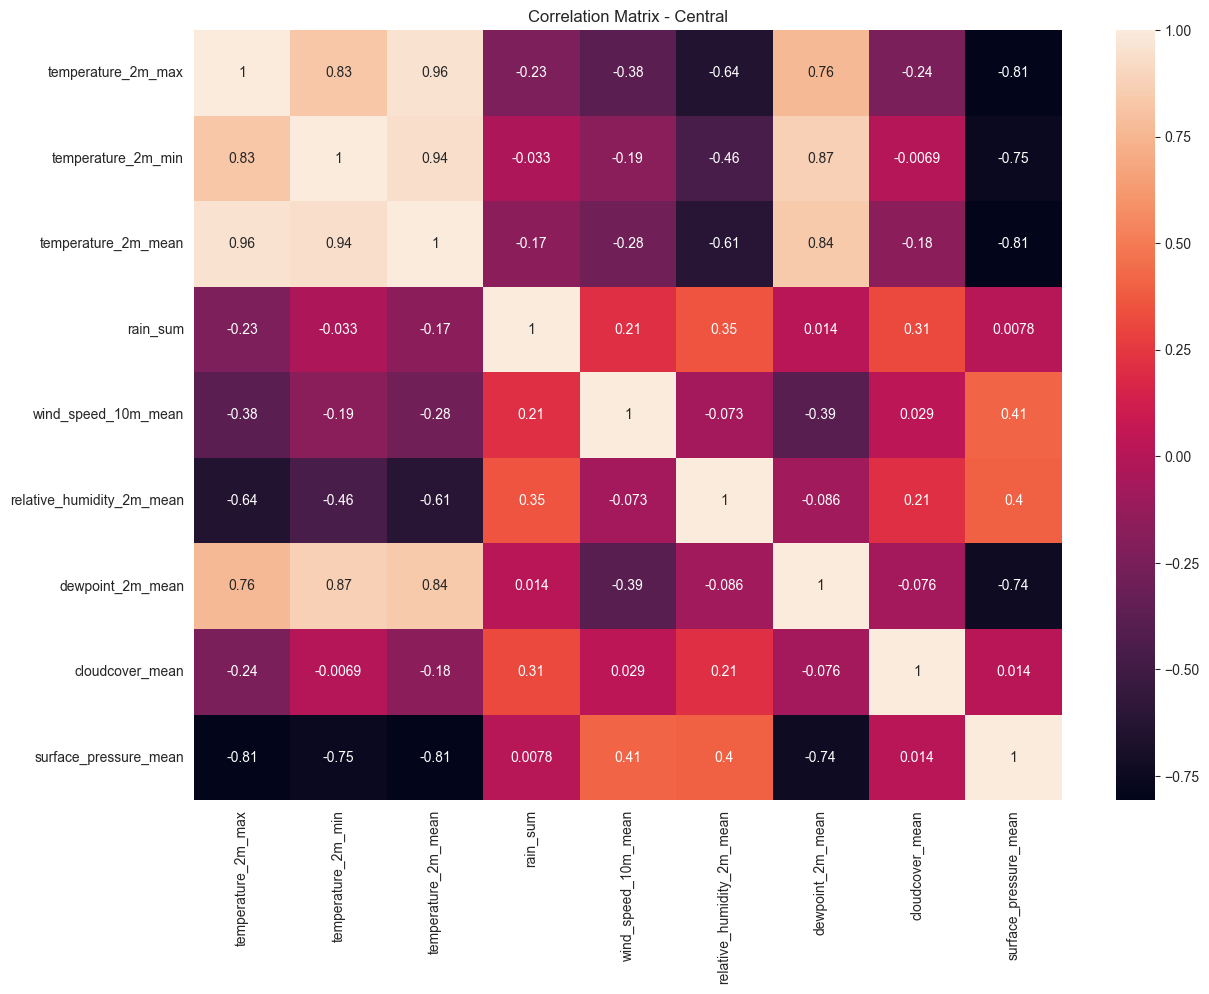

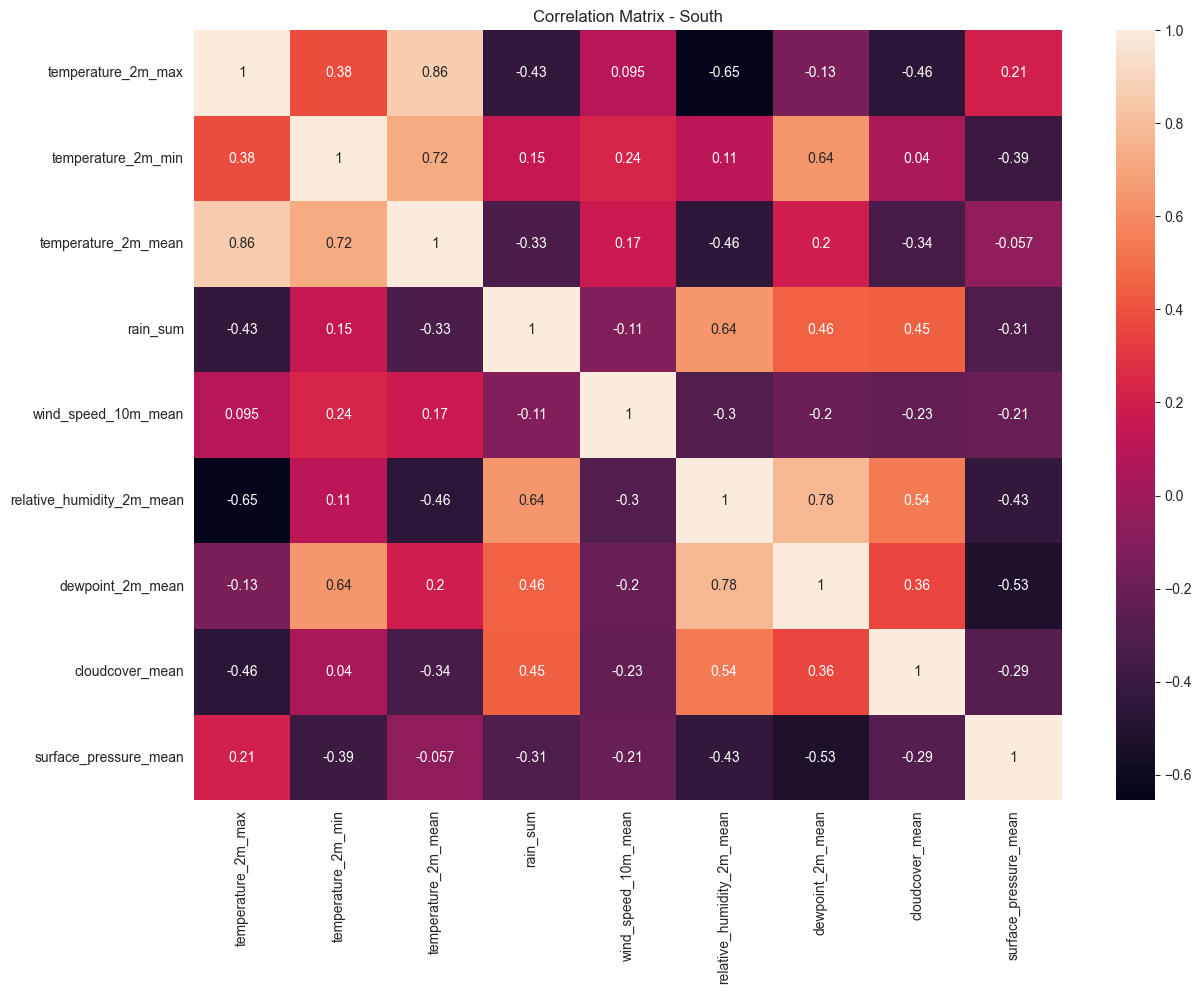

In [38]:
corr_cols = numeric_cols

for region_name, region_df in data_vungmien.items():
    plt.figure(figsize=(14,10))
    sns.heatmap(region_df[corr_cols].corr(), annot=True)
    plt.title(f"Correlation Matrix - {region_name}")
    plt.show()

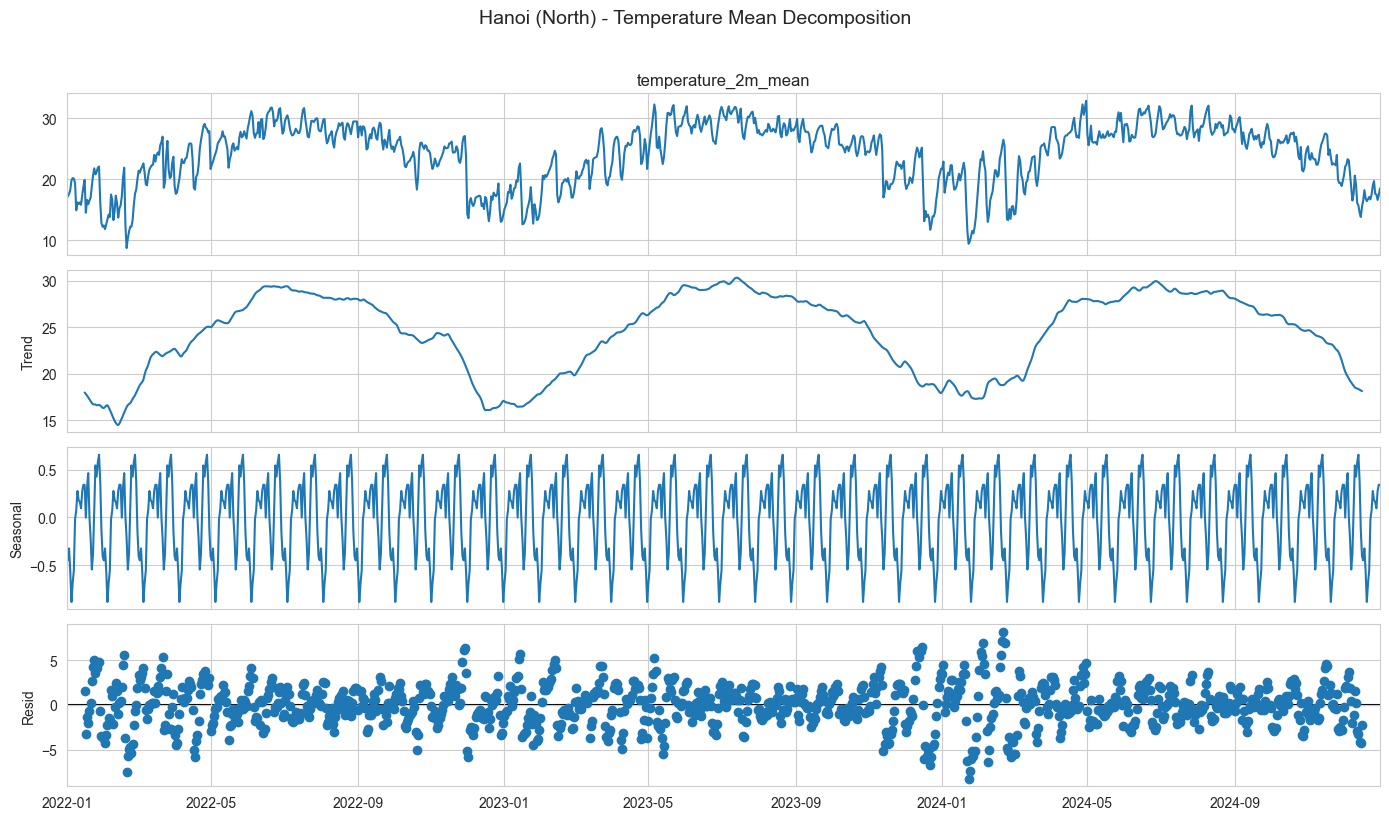

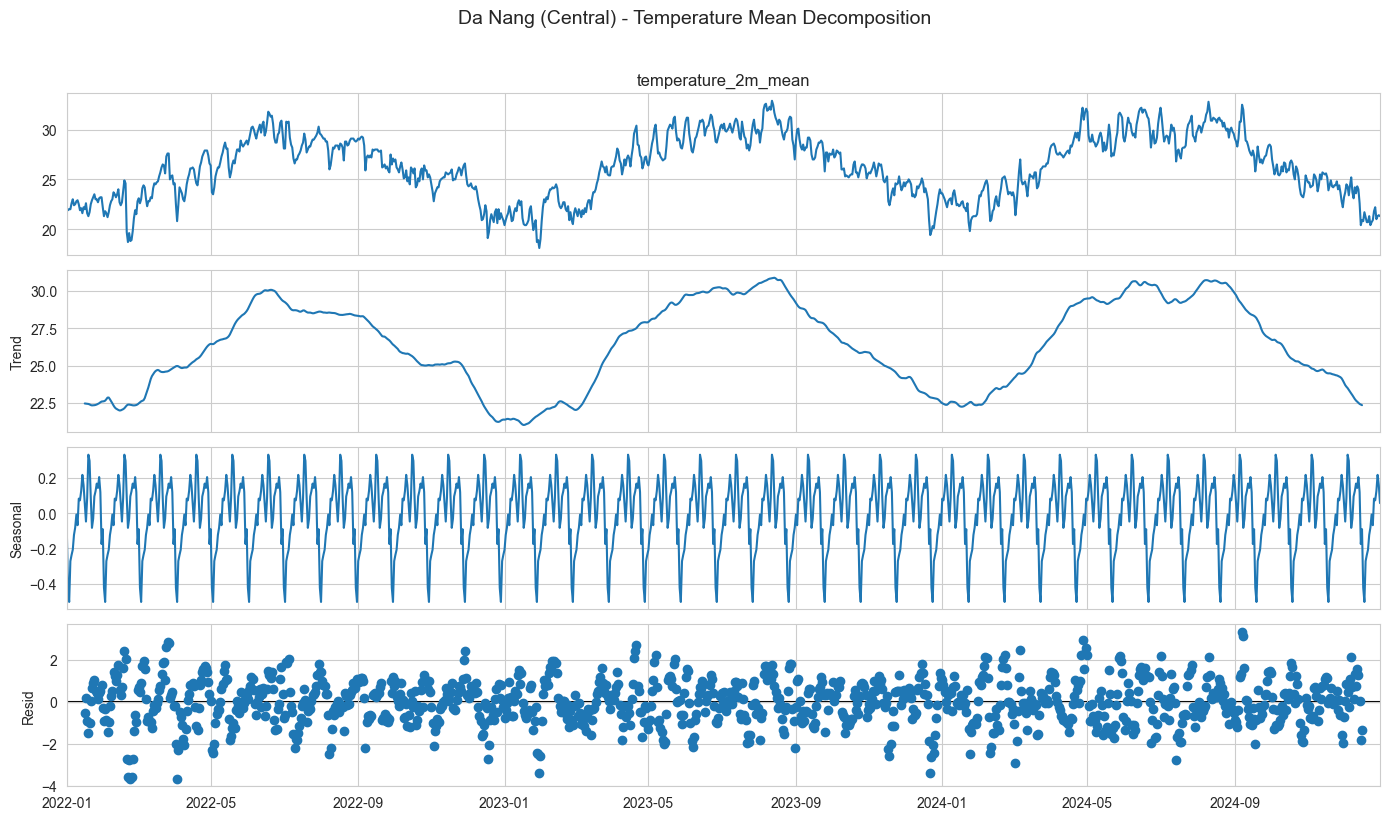

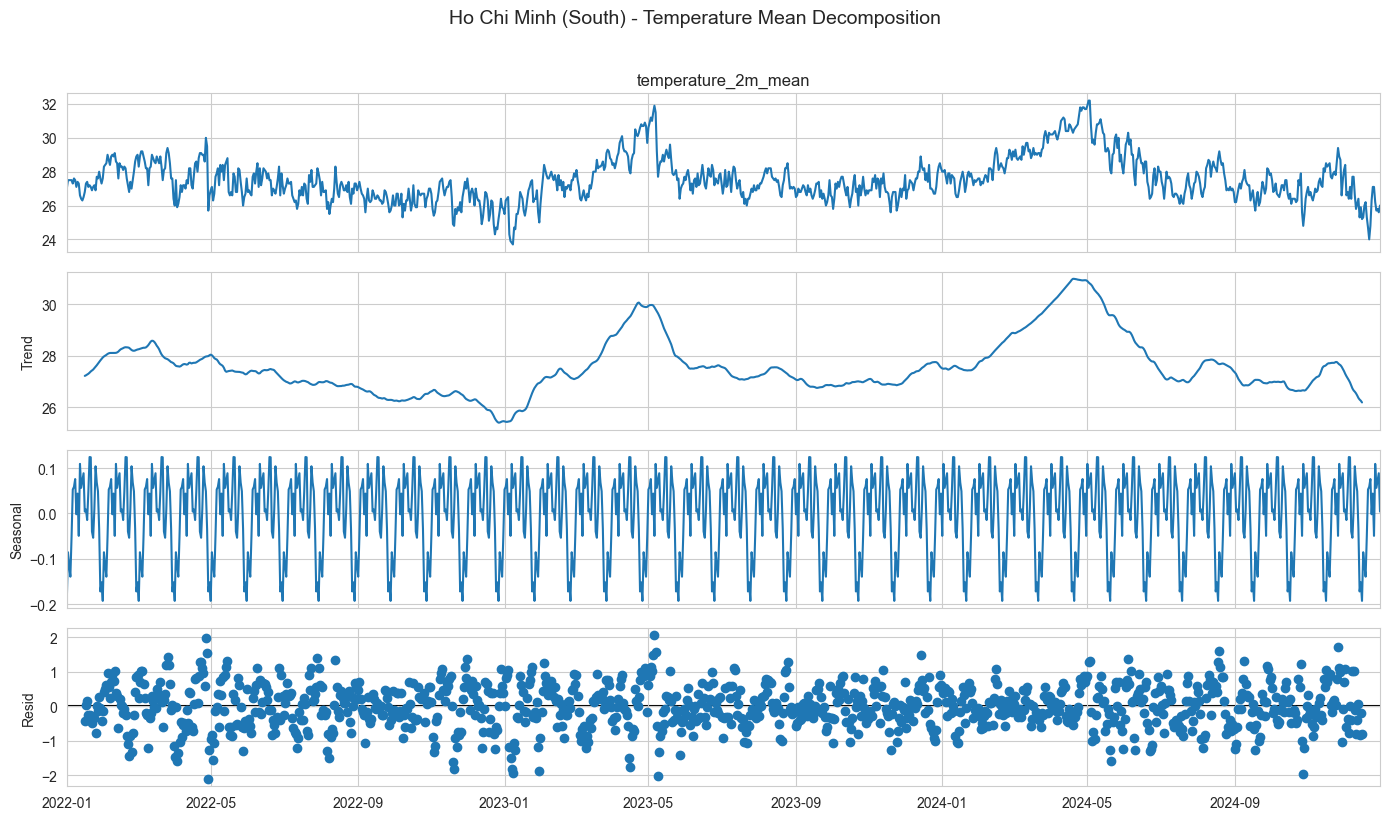

In [39]:
from statsmodels.tsa.seasonal import seasonal_decompose

sample_cities = {
    'North': 'Hanoi',
    'Central': 'Da Nang',
    'South': 'Ho Chi Minh'
}

for region, city in sample_cities.items():
    city_df = data_thanhpho[city].set_index('date').sort_index()

    result = seasonal_decompose(
        city_df['temperature_2m_mean'],
        model='additive',
        period=30              # daily data, khoảng 1 tháng
    )
    
    fig = result.plot()
    fig.set_size_inches(14, 8)
    fig.suptitle(f"{city} ({region}) - Temperature Mean Decomposition",
                 y=1.02, fontsize=14)
    fig.tight_layout()
    plt.show()

1. Hà Nội (North) – Seasonal Decomposition

📌 Observed (nhiệt độ thực tế)

+ Biến động rất lớn: 10°C → 32°C

+ Xuất hiện nhiều pha chu kỳ rõ rệt → 4 mùa đặc trưng

+ Đây là thành phố có biến thiên nhiệt độ mạnh nhất trong 3 vùng

📈 Trend (xu hướng dài hạn)

+ Xu hướng tạo thành sóng lớn:

+ Tháng 12–2: nhiệt độ giảm mạnh, đáy ~15°C

+ Tháng 5–8: nhiệt độ đạt đỉnh ~30°C

+ Chu kỳ trend lập lại đều mỗi năm → đặc trưng mùa đông – mùa hè rõ ràng

+ Dao động trend rộng → mô hình cần seasonality mạnh (năm)

🔁 Seasonal (chu kỳ trong năm)

+ Biên độ seasonal rất lớn (±0.5°C)

+ Chu kỳ 30 ngày rõ ràng → cho thấy pattern theo tháng/quý

+ Đường seasonal sắc nét, lặp lại đều → chứng tỏ nhiệt độ Bắc Bộ chịu ảnh hưởng chu kỳ tháng mạnh

⚡ Residual (nhiễu)

+ Biên độ nhiễu lớn (~±5°C)

+ Xuất hiện nhiều điểm bất thường (front lạnh, không khí lạnh, mưa rào bất chợt)

✔ Kết luận cho Hà Nội

+ Seasonal & trend mạnh → cần mô hình SARIMA, LSTM theo mùa, Prophet

+ Nhiễu cao → có thể kết hợp thêm XGBoost để sửa dự báo sai lệch

+ Cần tạo lag dài: lag 7, 14, 30, 365

2. Đà Nẵng (Central) – Seasonal Decomposition

📌 Observed

+ Biến thiên từ 20°C → 33°C, thấp hơn Hà Nội nhưng vẫn rõ rệt

+ Có sự thay đổi mạnh vào các tháng mưa bão (~10–12)

📈 Trend

+ Chu kỳ năm rõ:

+ Nóng nhất tháng 5–8 (~30–32°C)

+ Mát nhất vào mùa mưa (tháng 10–12) khoảng 22–24°C

+ Trend thoải hơn miền Bắc nhưng rất nhất quán theo mùa
→ Miền Trung có 2 mùa: khô nóng – mưa lạnh

🔁 Seasonal

+ Seasonal lặp đều 30 ngày nhưng biên độ nhỏ hơn miền Bắc

+ Mùa mưa có ảnh hưởng nhẹ đến seasonal nhưng không làm thay đổi biên độ nhiều

⚡ Residual

+ Nhiễu cũng không nhỏ, biên độ ±3°C

+ Một số spike ngẫu nhiên → thường do áp thấp nhiệt đới hoặc bão

✔ Kết luận cho Đà Nẵng

+ Seasonality có nhưng nhẹ hơn miền Bắc

+ Residual do bão gây nhiễu mạnh → dự báo khó hơn miền Nam

+ Cần lag vừa (7, 14, 30), không cần lag năm mạnh như miền Bắc

+ Model phù hợp: LSTM + XGBoost, Prophet vẫn ổn

3. Hồ Chí Minh (South) – Seasonal Decomposition

📌 Observed

+ Biến thiên nhỏ nhất: 26°C → 31°C

+ Khí hậu nóng quanh năm, đúng kiểu miền Nam

+ Ít mùa lạnh → chuỗi thời gian gần như ổn định

📈 Trend

+ Xu hướng gần như phẳng, chỉ dao động nhẹ theo năm

+ Có 1 đợt nhiệt độ giảm ngắn vào khoảng tháng 12–2 nhưng rất nhẹ (~1°C)

🔁 Seasonal

+ Seasonal rõ nhưng biên độ thấp nhất trong 3 vùng (~±0.15°C)

+ Lặp lại chu kỳ mỗi 30 ngày, biểu hiện mùa mưa – khô nhẹ

+ Không có seasonal lạnh sâu như miền Bắc

⚡ Residual

+ Nhiễu nhỏ (~±2°C)

+ Spike ít → thời tiết ổn định
→ Đây là vùng dễ dự báo nhất

✔ Kết luận cho Hồ Chí Minh

+ Seasonal yếu → mô hình đơn giản vẫn tốt

+ Mưa theo mùa nhưng nhiệt độ ổn định

+ Lag cần ít (1–7 ngày là đủ)

+ Model phù hợp: LSTM đơn giản, Linear regression, XGBoost